# <a id='toc1_'></a>[Data Mining - Part 1](#toc0_)<br>
Athors: Bezalel Spolter and Eden Philosoph

## <a id='toc1_1_'></a>[General Steps](#toc0_)

Importing relevant packages

In [237]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

%matplotlib inline
sns.set(color_codes=True) 
sns.set(rc={'figure.figsize':(5,5)}) 

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


Reading the file and showing first rows to understand gist of data

In [238]:
df = pd.read_csv("C:/Users/bezzs/OneDrive/Documents/אוניברסיטה/סמסטר ו/כריית מידע וייצוג מידע/פרויקט\churn_dataset_train.csv")
df.head(15)


,Unnamed: 0,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn
0,1644,fffe43004900440033003200390032003400,Dusty Dunneback,30,F,URPJZ5B,Village,No Membership,09/08/2017,Yes,CID49268,Gift Vouchers/Coupons,Desktop,Mobile_Data,20,118.390000,10579.56,24,610.360000,Yes,No,No,Not Applicable,Poor Product Quality,1
1,8516,fffe43004900440036003200310038003600,Dorine Vanduyn,55,M,O0IWUYW,Village,Silver Membership,09/02/2016,No,NaN,Credit/Debit Card Offers,Smartphone,Wi-Fi,15,179.420000,22963.05,27,694.650000,Yes,No,No,Not Applicable,Poor Product Quality,0
2,15564,fffe430049004400350032003200,Christene Pulver,47,M,2R0EFA2,City,Basic Membership,11/06/2017,Yes,CID23438,Credit/Debit Card Offers,NaN,Wi-Fi,23,42.230000,32604.41,Error,520.620000,Yes,No,No,Not Applicable,Poor Product Quality,1
3,22211,fffe43004900440032003200380034003600,Brendan Enciso,18,M,XF0YGUT,Town,Gold Membership,09/02/2016,No,NaN,Credit/Debit Card Offers,Desktop,Mobile_Data,7,-1035.833706,48913.61,27,1150.093442,Yes,No,No,Not Applicable,Too many ads,0
4,32088,fffe43004900440035003600320032003100,Lizette Lemons,28,F,V5YZC2N,City,No Membership,16/07/2017,Yes,NaN,Credit/Debit Card Offers,Both,Fiber_Optic,10,449.770000,20010.02,14,653.040000,Yes,Yes,Yes,No Information Available,No reason specified,0
5,15330,fffe43004900440034003500300038003800,Vera Hartzler,45,M,6PI2Y1B,Village,Gold Membership,15/02/2017,Yes,CID16576,Without Offers,Smartphone,Fiber_Optic,14,159.170000,48040.07,13,679.070000,No,Yes,No,Not Applicable,Poor Product Quality,0
6,2253,fffe43004900440033003400340030003800,Minerva Emmons,44,F,NC94WL3,City,Basic Membership,11/12/2016,No,NaN,Credit/Debit Card Offers,Both,Fiber_Optic,13,443.840000,30913.21,Error,695.040000,Yes,No,No,Not Applicable,Too many ads,1
7,18278,fffe43004900440036003200380037003800,Ming Shealy,59,F,F8RLNDC,Town,Gold Membership,03/06/2015,Yes,CID63534,Gift Vouchers/Coupons,NaN,Fiber_Optic,12,34.840000,29838.99,29,1240.381022,No,Yes,No,Not Applicable,No reason specified,0
8,24705,fffe43004900440031003500300038003900,Madalyn Aumick,16,M,S0CE1NE,City,Silver Membership,31/12/2015,No,NaN,Gift Vouchers/Coupons,Smartphone,Fiber_Optic,13,383.950000,68499.01,11,732.920000,Yes,Yes,Yes,Unsolved,Products always in Stock,0
9,7987,fffe43004900440034003700300037003100,Gina Piermarini,47,M,C2VAPSR,Town,Silver Membership,08/04/2017,Yes,CID30764,Gift Vouchers/Coupons,Smartphone,Wi-Fi,13,65.890000,42054.69,26,653.460000,No,Yes,Yes,Solved in Follow-up,Poor Customer Service,0


In [239]:
df.describe(include='all')

,Unnamed: 0,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn
count,24784.000000,24784,24784,24784.000000,24784,24784,21087,24784,24784,21158,12787,24576,21156,24784,24784.000000,24784.000000,24784.000000,24784,22497.000000,24784,24784,24784,24784,24784,24784.000000
unique,NaN,24784,24784,NaN,3,24784,3,6,1096,2,8738,3,3,3,NaN,NaN,NaN,1110,NaN,2,2,2,5,9,NaN
top,NaN,fffe43004900440032003300390031003800,Elden Bradham,NaN,F,NMF4QR4,Town,Basic Membership,24/09/2016,No,CID3979,Gift Vouchers/Coupons,Smartphone,Wi-Fi,NaN,NaN,NaN,Error,NaN,Yes,Yes,No,Not Applicable,Poor Product Quality,NaN
freq,NaN,1,1,NaN,12464,1,9476,5194,39,10653,10,8305,9388,8354,NaN,NaN,NaN,2353,NaN,13614,13716,12513,12513,4309,NaN
mean,18467.497014,NaN,NaN,36.986967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-42.462314,241.974449,29307.237880,NaN,686.287574,NaN,NaN,NaN,NaN,NaN,0.265655
std,10660.308320,NaN,NaN,15.860701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,229.834676,395.333687,19436.878248,NaN,193.175055,NaN,NaN,NaN,NaN,NaN,0.441690
min,0.000000,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-999.000000,-2281.236526,800.460000,NaN,-549.357498,NaN,NaN,NaN,NaN,NaN,0.000000
25%,9262.750000,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,60.165000,14194.192500,NaN,616.410000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,18495.500000,NaN,NaN,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,161.390000,27612.555000,NaN,696.920000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,27676.250000,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,354.725000,40862.025000,NaN,763.090000,NaN,NaN,NaN,NaN,NaN,1.000000


Seeing how many null there are and what data type each column is

In [240]:
df.iloc[:,:].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24784 entries, 0 to 24783
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    24784 non-null  int64  
 1   customer_id                   24784 non-null  object 
 2   Name                          24784 non-null  object 
 3   age                           24784 non-null  int64  
 4   gender                        24784 non-null  object 
 5   security_no                   24784 non-null  object 
 6   region_category               21087 non-null  object 
 7   membership_category           24784 non-null  object 
 8   joining_date                  24784 non-null  object 
 9   joined_through_referral       21158 non-null  object 
 10  referral_id                   12787 non-null  object 
 11  preferred_offer_types         24576 non-null  object 
 12  medium_of_operation           21156 non-null  object 
 13  i

In [241]:

# Check the data types of each column in the subset
categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(exclude='object').columns

# Identify categorical columns with all unique values (to move to "others")
unique_categorical_columns = df[categorical_columns].columns[df[categorical_columns].nunique() == len(df)]

# Remove those unique categorical columns from categorical list
categorical_columns = categorical_columns.difference(unique_categorical_columns)

# Check for columns where all values are unique (this will include unique categorical columns)
unique_columns = unique_categorical_columns

# Function to count nulls and format the column names
def count_nulls_and_format(column):
    null_count = df_subset[column].isnull().sum()
    return f"- {column} - (Null values: {null_count})" if null_count > 0 else f"- {column}"

def print_column_info(categorical_columns, numerical_columns, unique_columns, df_subset):
    # Function to count nulls and format the column names
    def count_nulls_and_format(column):
        null_count = df_subset[column].isnull().sum()
        return f"- {column} ({df[column].dtype}) - (Null values: {null_count})" if null_count > 0 else f"- {column} ({df[column].dtype})"

    # Print categorical columns
    print("--------------------------------------------------")
    print("Categorical columns (excluding those with all unique values):")
    print("--------------------------------------------------")
    if len(categorical_columns) > 0:
        for col in categorical_columns:
            print(count_nulls_and_format(col))
    else:
        print("No categorical columns with non-unique values.")

    # Print numerical columns
    print("\n--------------------------------------------------")
    print("Numerical columns:")
    print("--------------------------------------------------")
    if len(numerical_columns) > 0:
        for col in numerical_columns:
            print(count_nulls_and_format(col))
    else:
        print("No numerical columns.")

    # Print columns where all values are unique (both unique categorical and others)
    print("\n--------------------------------------------------")
    print("'Other' columns (categorical with all unique values):")
    print("--------------------------------------------------")
    if len(unique_columns) > 0:
        for col in unique_columns:
            print(count_nulls_and_format(col))
    else:
        print("No categorical columns with all unique values.")
print_column_info(categorical_columns, numerical_columns, unique_columns, df)


--------------------------------------------------
Categorical columns (excluding those with all unique values):
--------------------------------------------------
- avg_frequency_login_days (object)
- complaint_status (object)
- feedback (object)
- gender (object)
- internet_option (object)
- joined_through_referral (object) - (Null values: 3626)
- joining_date (object)
- medium_of_operation (object) - (Null values: 3628)
- membership_category (object)
- offer_application_preference (object)
- past_complaint (object)
- preferred_offer_types (object) - (Null values: 208)
- referral_id (object) - (Null values: 11997)
- region_category (object) - (Null values: 3697)
- used_special_discount (object)

--------------------------------------------------
Numerical columns:
--------------------------------------------------
- Unnamed: 0 (int64)
- age (int64)
- days_since_last_login (int64)
- avg_time_spent (float64)
- avg_transaction_value (float64)
- points_in_wallet (float64) - (Null values:

It seems like there are 24,784 people in the dataset. And there are a some columns which have null values in them. <br>
However, in Categorical - 'avg_frequency_login_days' seems to be a column that should be in numerical but it is classified an object.
Will have to convert to number later. <br>
Additionally, in Numerical - 'churn' gets values only 1 or 0 therefore should be in Categorical

In [242]:
# Define 'Other' category as a list to store columns that don't fit into numerical or categorical
other_columns = list(unique_columns)  # Start with unique columns (all unique values)

# Check if 'Unnamed: 0' is in the DataFrame and add to 'Other' if it exists
if 'Unnamed: 0' in df.columns and 'Unnamed: 0' not in other_columns:
    other_columns.append('Unnamed: 0')

# Remove 'Unnamed: 0' from numerical_columns (if it's there)
numerical_columns = numerical_columns.difference(['Unnamed: 0'])

# Add 'avg_frequency_login_days' to numerical columns and 'churn' to categorical columns
numerical_columns = numerical_columns.append(pd.Index(['avg_frequency_login_days']))
categorical_columns = categorical_columns.append(pd.Index(['churn']))

# Remove 'avg_frequency_login_days' from categorical_columns if it exists there
categorical_columns = categorical_columns.difference(['avg_frequency_login_days'])

# Remove 'churn' from numerical_columns if it exists there
numerical_columns = numerical_columns.difference(['churn'])

# Print out the final categorized columns
print("--------------------------------------------------")
print("Categorical Columns:")
print(categorical_columns.tolist())

print("\nNumerical Columns:")
print(numerical_columns.tolist())

print("\nOther Columns (Unique values or ID-like):")
print(other_columns)


--------------------------------------------------
Categorical Columns:
['churn', 'complaint_status', 'feedback', 'gender', 'internet_option', 'joined_through_referral', 'joining_date', 'medium_of_operation', 'membership_category', 'offer_application_preference', 'past_complaint', 'preferred_offer_types', 'referral_id', 'region_category', 'used_special_discount']

Numerical Columns:
['age', 'avg_frequency_login_days', 'avg_time_spent', 'avg_transaction_value', 'days_since_last_login', 'points_in_wallet']

Other Columns (Unique values or ID-like):
['customer_id', 'Name', 'security_no', 'Unnamed: 0']


We know that some of the numerical columns have negatives or Error which are bad. So we would like to count how many bad rows there are:

In [243]:

# Define a function to check if a row is "bad"
def is_bad_row(row):
    bad_columns = 0
    # Check for null values in any column, except 'referral_id'
    for col in df.columns:
        if col != 'referral_id' and pd.isnull(row[col]):
            bad_columns += 1
    
    # Check if 'avg_frequency_login_days' column has negative or "Error" value
    if 'avg_frequency_login_days' in df.columns:
        value = row['avg_frequency_login_days']
        if value == 'Error' or (isinstance(value, str) and value.replace('.', '', 1).isdigit() and float(value) < 0):
            bad_columns += 1

    return bad_columns

# Apply the function across all rows and store the count of bad columns
df['bad_columns'] = df.apply(is_bad_row, axis=1)

# Calculate how many rows have the same number of bad columns
bad_column_counts = df['bad_columns'].value_counts().to_dict()

# Output the results
for num_bad_cols, num_rows in bad_column_counts.items():
    print(f'Number of bad columns in the row: {num_bad_cols}, Number of rows with that number of bad columns: {num_rows}')

Number of bad columns in the row: 0, Number of rows with that number of bad columns: 12537
Number of bad columns in the row: 1, Number of rows with that number of bad columns: 9146
Number of bad columns in the row: 2, Number of rows with that number of bad columns: 2682
Number of bad columns in the row: 3, Number of rows with that number of bad columns: 387
Number of bad columns in the row: 4, Number of rows with that number of bad columns: 32


We assume that 3 or 4 bad columns in a person's row of data makes it a bad row so we would like to drop them

In [244]:
# Drop rows with 3 or more bad columns and update df directly
df = df[df['bad_columns'] < 3].copy()

# Drop the 'bad_columns' helper column
df = df.drop(columns=['bad_columns'])

print(f"Rows after cleaning: {len(df)}")


Rows after cleaning: 24365


Now we will start looking at the columns and analyzing them

## Unique Columns

### Unnamed Column

In [245]:
df['Unnamed: 0'].nunique()

24365

We dropped the first column because it doesn't give any information:

In [246]:
df = df.drop('Unnamed: 0', axis=1)


In [247]:
print("Shape: ", df.shape)
pd.set_option('display.max_columns', None)
df.head()

Shape:  (24365, 24)


,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn
0,fffe43004900440033003200390032003400,Dusty Dunneback,30,F,URPJZ5B,Village,No Membership,09/08/2017,Yes,CID49268,Gift Vouchers/Coupons,Desktop,Mobile_Data,20,118.390000,10579.56,24,610.360000,Yes,No,No,Not Applicable,Poor Product Quality,1
1,fffe43004900440036003200310038003600,Dorine Vanduyn,55,M,O0IWUYW,Village,Silver Membership,09/02/2016,No,NaN,Credit/Debit Card Offers,Smartphone,Wi-Fi,15,179.420000,22963.05,27,694.650000,Yes,No,No,Not Applicable,Poor Product Quality,0
2,fffe430049004400350032003200,Christene Pulver,47,M,2R0EFA2,City,Basic Membership,11/06/2017,Yes,CID23438,Credit/Debit Card Offers,NaN,Wi-Fi,23,42.230000,32604.41,Error,520.620000,Yes,No,No,Not Applicable,Poor Product Quality,1
3,fffe43004900440032003200380034003600,Brendan Enciso,18,M,XF0YGUT,Town,Gold Membership,09/02/2016,No,NaN,Credit/Debit Card Offers,Desktop,Mobile_Data,7,-1035.833706,48913.61,27,1150.093442,Yes,No,No,Not Applicable,Too many ads,0
4,fffe43004900440035003600320032003100,Lizette Lemons,28,F,V5YZC2N,City,No Membership,16/07/2017,Yes,NaN,Credit/Debit Card Offers,Both,Fiber_Optic,10,449.770000,20010.02,14,653.040000,Yes,Yes,Yes,No Information Available,No reason specified,0


### customer_id

In [248]:
df['customer_id'].nunique()

24365

### Name

In [249]:
df['Name'].nunique()

24365

### security_no

In [250]:
df['security_no'].nunique()

24365

We dropped this column because it doesn't give any information:

In [251]:
df = df.drop('security_no', axis=1)


In [252]:
print("Shape: ", df.shape)
pd.set_option('display.max_columns', None)
df.head()

Shape:  (24365, 23)


,customer_id,Name,age,gender,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn
0,fffe43004900440033003200390032003400,Dusty Dunneback,30,F,Village,No Membership,09/08/2017,Yes,CID49268,Gift Vouchers/Coupons,Desktop,Mobile_Data,20,118.390000,10579.56,24,610.360000,Yes,No,No,Not Applicable,Poor Product Quality,1
1,fffe43004900440036003200310038003600,Dorine Vanduyn,55,M,Village,Silver Membership,09/02/2016,No,NaN,Credit/Debit Card Offers,Smartphone,Wi-Fi,15,179.420000,22963.05,27,694.650000,Yes,No,No,Not Applicable,Poor Product Quality,0
2,fffe430049004400350032003200,Christene Pulver,47,M,City,Basic Membership,11/06/2017,Yes,CID23438,Credit/Debit Card Offers,NaN,Wi-Fi,23,42.230000,32604.41,Error,520.620000,Yes,No,No,Not Applicable,Poor Product Quality,1
3,fffe43004900440032003200380034003600,Brendan Enciso,18,M,Town,Gold Membership,09/02/2016,No,NaN,Credit/Debit Card Offers,Desktop,Mobile_Data,7,-1035.833706,48913.61,27,1150.093442,Yes,No,No,Not Applicable,Too many ads,0
4,fffe43004900440035003600320032003100,Lizette Lemons,28,F,City,No Membership,16/07/2017,Yes,NaN,Credit/Debit Card Offers,Both,Fiber_Optic,10,449.770000,20010.02,14,653.040000,Yes,Yes,Yes,No Information Available,No reason specified,0


## <a id='toc1_2_'></a>[Numerical Columns](#toc0_)

In [253]:
# Describe only the numerical columns
df[numerical_columns].describe()

,age,avg_time_spent,avg_transaction_value,days_since_last_login,points_in_wallet
count,24365.000000,24365.000000,24365.000000,24365.000000,22283.000000
mean,36.984691,241.691940,29301.687730,-42.539709,686.290747
std,15.855743,395.815189,19446.196447,229.985746,193.095242
min,10.000000,-2281.236526,800.460000,-999.000000,-549.357498
25%,23.000000,60.150000,14180.090000,8.000000,616.295000
50%,37.000000,161.570000,27606.580000,12.000000,696.910000
75%,51.000000,354.660000,40849.420000,16.000000,763.130000
max,64.000000,3040.410000,99914.050000,26.000000,1816.933696


In [254]:
df['avg_frequency_login_days'].describe()

count     24365
unique     1101
top       Error
freq       2142
Name: avg_frequency_login_days, dtype: object

We can see the for 'avg_frequency_login_days' the top value is 'Error'. This means that this is another column with "Null" values to deal with. <br>
The columns with "Null" to be dealt with: 'avg_frequency_login_days' , 'points_in_wallet' <br><br>
Now we will go over each column and understand it

### age

In [255]:
print(df['age'].describe())


count    24365.000000
mean        36.984691
std         15.855743
min         10.000000
25%         23.000000
50%         37.000000
75%         51.000000
max         64.000000
Name: age, dtype: float64


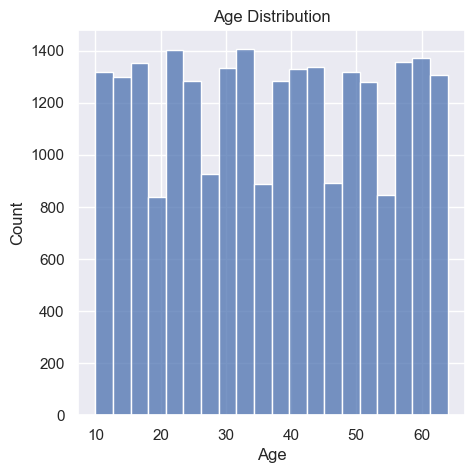

In [256]:

sns.histplot(df, x='age', bins=20, kde=False)  # Pass the DataFrame directly
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


In [257]:
# Count how many people are under 16
under_16_count = df[df['age'] < 16].shape[0]
print(f"Number of people under 16: {under_16_count}")

Number of people under 16: 2616


We can see that there are children under the age of 16 who shouldn't be using this app. <br> 
But maybe app rules allow this and parents are paying for them so therefore we will not change these values.

### joining_date

In [258]:
print(df['joining_date'].describe())


count          24365
unique          1096
top       24/09/2016
freq              39
Name: joining_date, dtype: object


Change joining_date's type from object to datetime:

In [259]:
df['joining_date'] = pd.to_datetime(df['joining_date'], format="%d/%m/%Y")

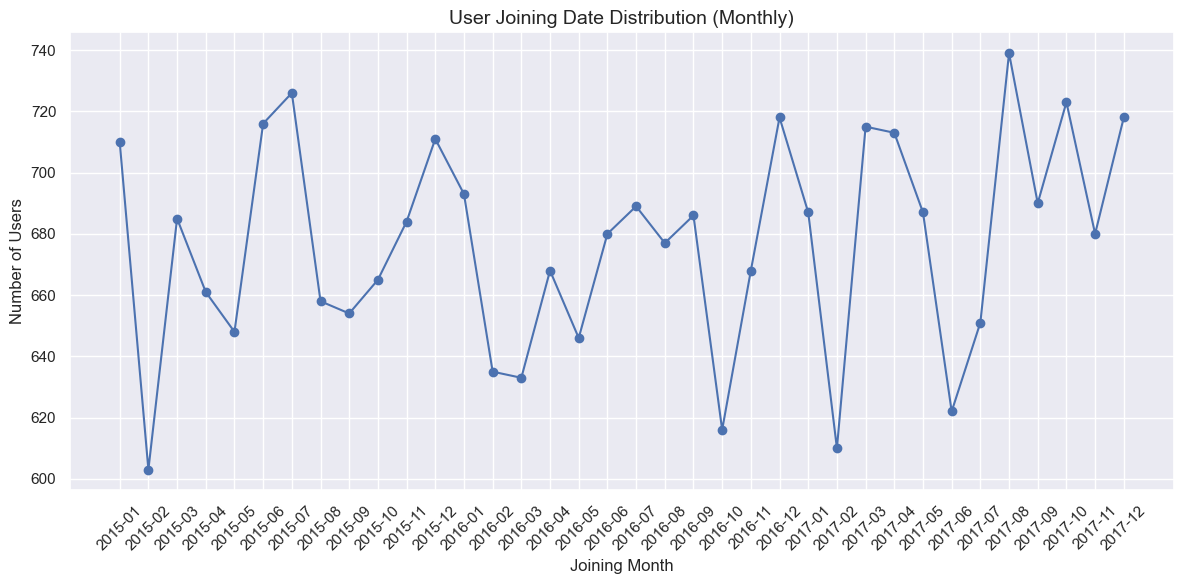

In [260]:
# Group by month
monthly_counts = df['joining_date'].dt.to_period('M').value_counts().sort_index()

# Plot line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_counts.index.astype(str), monthly_counts.values, marker='o', linestyle='-')
plt.title('User Joining Date Distribution (Monthly)', fontsize=14)
plt.xlabel('Joining Month', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### <a id='toc1_2_1_'></a>[avg_frequency_login_days](#toc0_)

In [261]:
print(df["avg_frequency_login_days"].head(15))


0        24
1        27
2     Error
3        27
4        14
5        13
6     Error
7        29
8        11
9        26
10        6
11        8
12       22
13       14
14    Error
Name: avg_frequency_login_days, dtype: object


We can see that there are "Error" values in the column. <br>
Now we will check all the kinds of unique data types in the column.

In [262]:
#Check the data types for each value in 'avg_frequency_login_days'
dtypes = df['avg_frequency_login_days'].apply(type)
unique_dtypes = dtypes.unique()

print(f"Unique data types in 'avg_frequency_login_days': {unique_dtypes}")

Unique data types in 'avg_frequency_login_days': [<class 'str'>]


We can see that the column is made up off strings. So we would like to convert to floats by making 'Error' Null and the numbers as strings into floats

In [263]:

# 1. Count the number of NaN (null) values before conversion - this is to make sure all Errors were turned into Nulls
num_nulls_before = df['avg_frequency_login_days'].isna().sum()
num_Error_before = df['avg_frequency_login_days'].astype(str).str.contains('Error', case=False, na=False).sum()
print(f"Number of NaN (null) values before conversion: {num_nulls_before}")
print(f"Number of rows with 'Error' in 'avg_frequency_login_days': {num_Error_before}")

# 2. Convert all numeric values to float and non-numeric values to NaN
df['avg_frequency_login_days'] = pd.to_numeric(df['avg_frequency_login_days'], errors='coerce')

# 3. Count the number of NaN (null) values after conversion
num_nulls_after = df['avg_frequency_login_days'].isna().sum()
print(f"Number of NaN (null) values after conversion: {num_nulls_after}")

try:
    # First, ensure that we only apply str.contains on non-NaN values
    num_Error_after = df['avg_frequency_login_days'].dropna().astype(str).str.contains('Error', case=False).sum()

    if num_Error_after == 0:
        print(f"There are no more errors.")
    else:
        print(f"Number of rows with 'Error' after conversion: {num_Error_after}")
except Exception as e:
    print("There are no values of error")

# 4. Handle non-null numeric values for summary (min, max, and distribution)
numeric_values = df['avg_frequency_login_days'].dropna()  # Remove NaN values

    


Number of NaN (null) values before conversion: 0
Number of rows with 'Error' in 'avg_frequency_login_days': 2142
Number of NaN (null) values after conversion: 2142
There are no more errors.


Now we look at the distribution of the column:

In [264]:
print(df["avg_frequency_login_days"].describe())
print("The skewness of the distribution is ",df["avg_frequency_login_days"].skew())



count    22223.000000
mean        15.987212
std          9.249301
min        -43.652702
25%          9.000000
50%         16.000000
75%         23.000000
max         67.062422
Name: avg_frequency_login_days, dtype: float64
The skewness of the distribution is  -0.01650617573455535


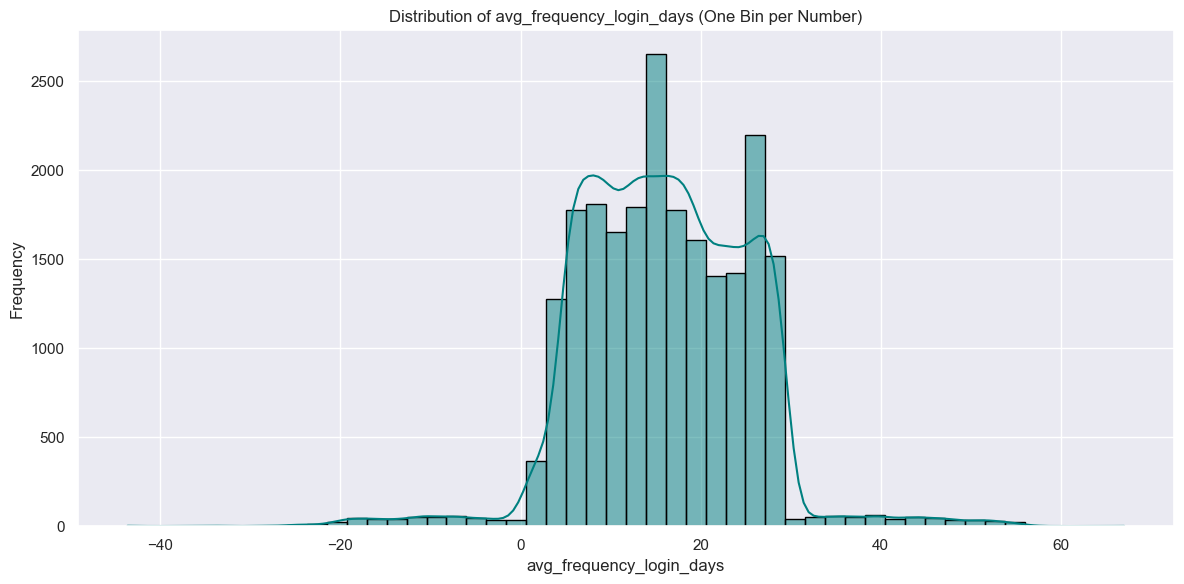

In [265]:
plt.figure(figsize=(12, 6))
sns.histplot(numeric_values, bins=50, kde=True, color='teal', edgecolor='black')
plt.title('Distribution of avg_frequency_login_days (One Bin per Number)')
plt.xlabel('avg_frequency_login_days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



We can see that there are many negative numbers. This should not be.

In [266]:
num_Neg_avg_frequency_login_days=(df["avg_frequency_login_days"] < 0).sum()
num_Null_avg_frequency_login_days=df["avg_frequency_login_days"].isna().sum()
print("There are",num_Neg_avg_frequency_login_days ,"negative values.")
print("There are",num_Null_avg_frequency_login_days ,"null values.")
print("Altogether there are",num_Neg_avg_frequency_login_days + num_Null_avg_frequency_login_days,"problematic values in this column")


There are 445 negative values.
There are 2142 null values.
Altogether there are 2587 problematic values in this column


The negative values we will make positive. The others we will make according to distrutions: <br>
We can see in the graph that there are two distributions: 0 to 30 and 30+. We make sure the proportions of the two subsets stay the same in the problematic values division and then each subset will be given value according to distribution of it's part in graph.

In [267]:
df['avg_frequency_login_days'] = df['avg_frequency_login_days'].abs()

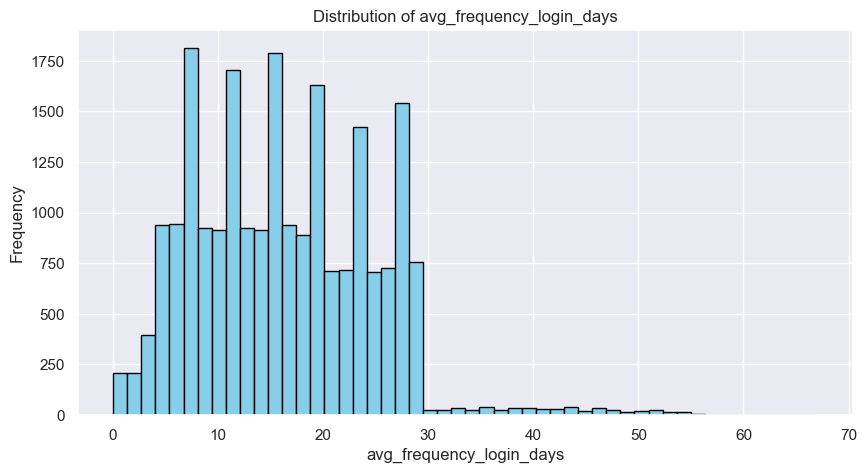

In [268]:
# Drop NaNs for this analysis
data = df['avg_frequency_login_days'].dropna()

# Plot histogram to visually inspect drop-off point
plt.figure(figsize=(10, 5))
plt.hist(data, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('avg_frequency_login_days')
plt.ylabel('Frequency')
plt.title('Distribution of avg_frequency_login_days')
plt.grid(True)
plt.show()


Percentage <= 30: 97.73%
Percentage > 30: 2.27%
Null values before imputation: 2142


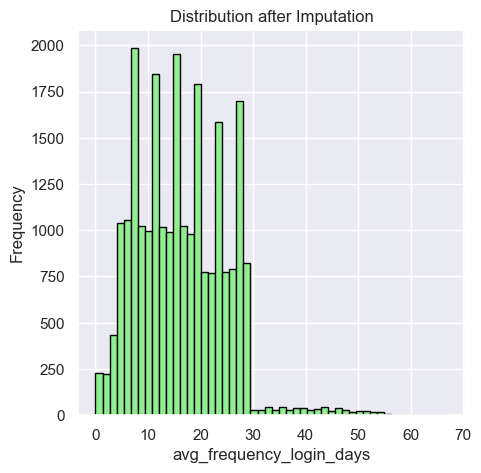

Null values after imputation: 0


In [269]:
# Define split point (adjust after you visually check)
split_point = 30

# Count proportions
below_split = data[data <= split_point]
above_split = data[data > split_point]

# Percentages
below_pct = len(below_split) / len(data)
above_pct = len(above_split) / len(data)

print(f"Percentage <= {split_point}: {below_pct * 100:.2f}%")
print(f"Percentage > {split_point}: {above_pct * 100:.2f}%")

# Count nulls
null_count = df['avg_frequency_login_days'].isna().sum()
print(f"Null values before imputation: {null_count}")

# Number of nulls to fill from each part
below_nulls = int(null_count * below_pct)
above_nulls = null_count - below_nulls  # remaining

# Randomly sample values for imputation
fill_below = below_split.sample(below_nulls, replace=True, random_state=42).values
fill_above = above_split.sample(above_nulls, replace=True, random_state=42).values

# Combine
filled_values = np.concatenate([fill_below, fill_above])
np.random.shuffle(filled_values)  # shuffle to mix them

# Fill nulls in the original dataframe
df.loc[df['avg_frequency_login_days'].isna(), 'avg_frequency_login_days'] = filled_values

df['avg_frequency_login_days'].hist(bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution after Imputation')
plt.xlabel('avg_frequency_login_days')
plt.ylabel('Frequency')
plt.show()

# Count nulls
null_count = df['avg_frequency_login_days'].isna().sum()
print(f"Null values after imputation: {null_count}")


In [270]:
from scipy.stats import skew

# Describe statistics
print(f"Statistics for values <= {split_point}:")
print(below_split.describe())
print(f"Skewness: {skew(below_split, nan_policy='omit'):.2f}")
print()

print(f"Statistics for values > {split_point}:")
print(above_split.describe())
print(f"Skewness: {skew(above_split, nan_policy='omit'):.2f}")

Statistics for values <= 30:
count    21718.000000
mean        15.857012
std          7.510773
min          0.006221
25%          9.357849
50%         16.000000
75%         22.000000
max         30.000000
Name: avg_frequency_login_days, dtype: float64
Skewness: 0.07

Statistics for values > 30:
count    505.000000
mean      41.534097
std        6.892342
min       30.166038
25%       35.812752
50%       40.645495
75%       46.533211
max       67.062422
Name: avg_frequency_login_days, dtype: float64
Skewness: 0.32


### <a id='toc1_2_2_'></a>[avg_time_spent](#toc0_)

In [271]:
print(df['avg_time_spent'].describe())
print("Skewness is: ", df['avg_time_spent'].skew())

count    24365.000000
mean       241.691940
std        395.815189
min      -2281.236526
25%         60.150000
50%        161.570000
75%        354.660000
max       3040.410000
Name: avg_time_spent, dtype: float64
Skewness is:  0.4965854366120871


We can see negative values

In [272]:
print("Number of negative values: ",(df['avg_time_spent'] < 0).sum())


Number of negative values:  1137


In [273]:
# Calculate the number of negative values
negative_count = (df['avg_time_spent'] < 0).sum()

# Calculate the total number of rows
total_count = len(df)

# Calculate the proportion of negative values
negative_proportion = negative_count / total_count

# Calculate min and max
min_value = df['avg_time_spent'].min()
max_value = df['avg_time_spent'].max()

# Print the results
print("Number of negative values: ", negative_count)
print(f"Percentage of negative values: {negative_proportion:.2%}")
print(f"Minimum value: {min_value}")
print(f"Maximum value: {max_value}")

Number of negative values:  1137
Percentage of negative values: 4.67%
Minimum value: -2281.236526
Maximum value: 3040.41


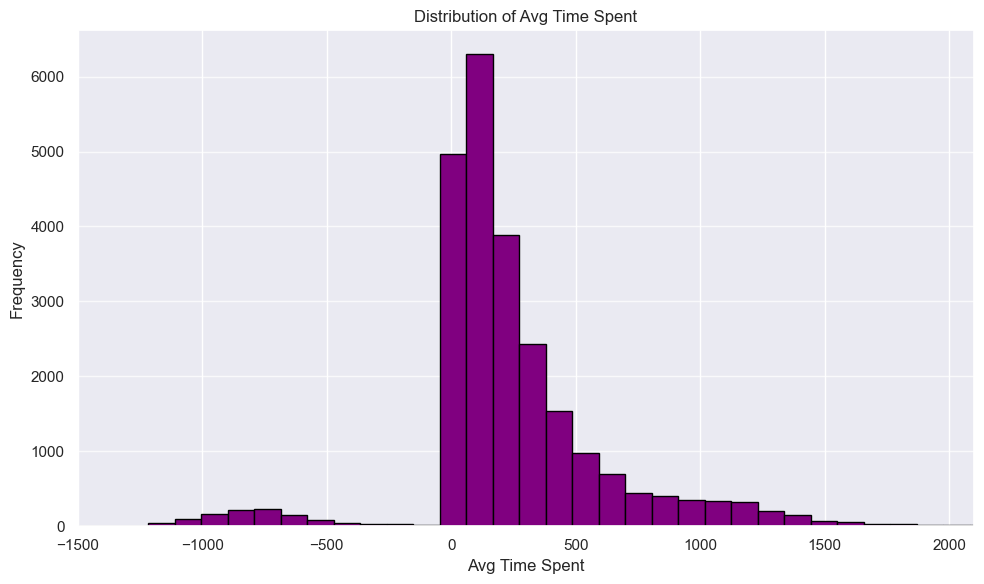

In [274]:
# Create the histogram for avg_time_spent
plt.figure(figsize=(10, 6))
plt.hist(df['avg_time_spent'].dropna(), bins=50, color='purple', edgecolor='black')

# Title and labels
plt.title('Distribution of Avg Time Spent')
plt.xlabel('Avg Time Spent')
plt.ylabel('Frequency')

# Adjust the x-axis limits to zoom in, just before the min and just after the max
plt.xlim(-1500, 2100)

# Adjust grid and layout
plt.grid(axis='y', linestyle='-', alpha=0.75)
plt.tight_layout()

# Show the plot
plt.show()

We can see many negative values. We are going to assume the minus was an error (the range of negative values is same as range of positive values)
<br>Let's make those values positive

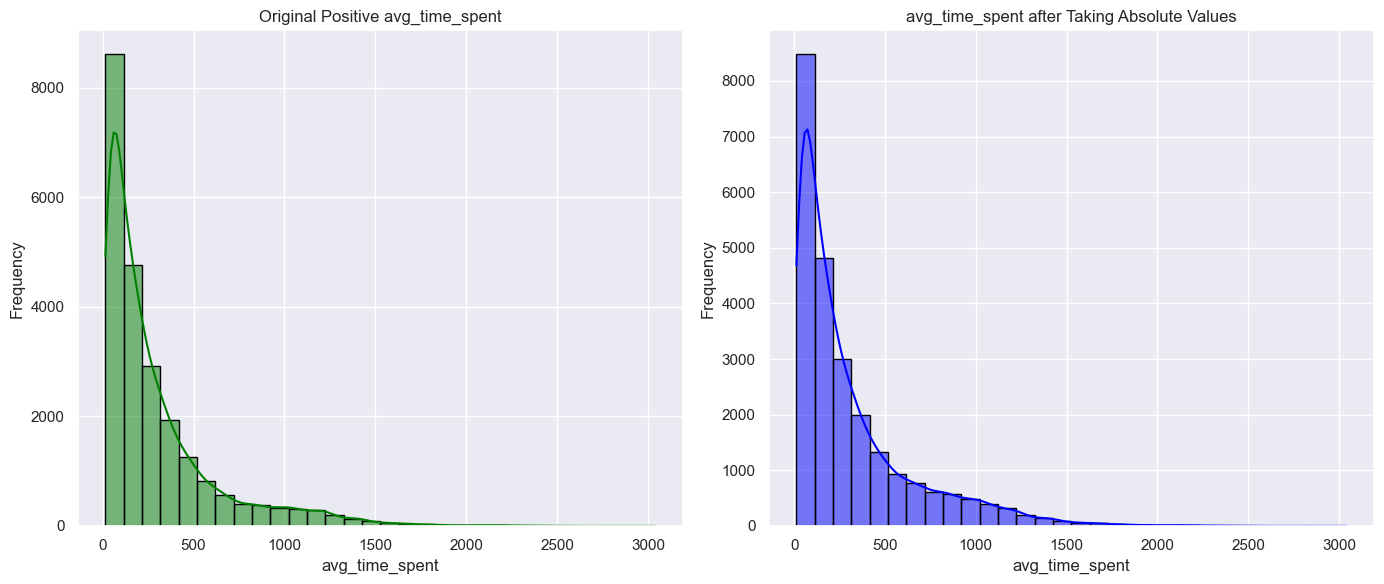

In [275]:
# 1. Filter positive values (before making any changes)
positive_only = df[df['avg_time_spent'] > 0]['avg_time_spent']

# 2. Make negative values positive (absolute value)
df['avg_time_spent'] = df['avg_time_spent'].abs()

# 3. Plot the two distributions side by side

plt.figure(figsize=(14, 6))

# Distribution of positive-only values
plt.subplot(1, 2, 1)
sns.histplot(positive_only, bins=30, kde=True, color='green', edgecolor='black')
plt.title('Original Positive avg_time_spent')
plt.xlabel('avg_time_spent')
plt.ylabel('Frequency')

# Distribution after making negatives positive
plt.subplot(1, 2, 2)
sns.histplot(df['avg_time_spent'], bins=30, kde=True, color='blue', edgecolor='black')
plt.title('avg_time_spent after Taking Absolute Values')
plt.xlabel('avg_time_spent')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Check to see if distributions are fairly the same

In [276]:
# 3. Define thresholds
thresholds = [100, 500, 1000, 1500]

# 4. Function to calculate empirical probabilities
def calculate_empirical_probabilities(data, thresholds):
    probs = {}
    total = len(data)
    for t in thresholds:
        prob = (data < t).sum() / total
        probs[t] = prob
    return probs

# 5. Calculate for both datasets
positive_probs = calculate_empirical_probabilities(positive_only, thresholds)
abs_probs = calculate_empirical_probabilities(df['avg_time_spent'], thresholds)

# 6. Print results
print("Empirical probabilities for ONLY positive values:")
for t in thresholds:
    print(f"P(avg_time_spent < {t}) = {positive_probs[t]:.4f}")

print("\nEmpirical probabilities for ALL values after taking ABS:")
for t in thresholds:
    print(f"P(avg_time_spent < {t}) = {abs_probs[t]:.4f}")

Empirical probabilities for ONLY positive values:
P(avg_time_spent < 100) = 0.3297
P(avg_time_spent < 500) = 0.8304
P(avg_time_spent < 1000) = 0.9440
P(avg_time_spent < 1500) = 0.9909

Empirical probabilities for ALL values after taking ABS:
P(avg_time_spent < 100) = 0.3150
P(avg_time_spent < 500) = 0.7975
P(avg_time_spent < 1000) = 0.9397
P(avg_time_spent < 1500) = 0.9904


count    24365.000000
mean       313.652498
std        341.621322
min         12.338460
25%         75.820000
50%        185.990000
75%        414.260000
max       3040.410000
Name: avg_time_spent, dtype: float64


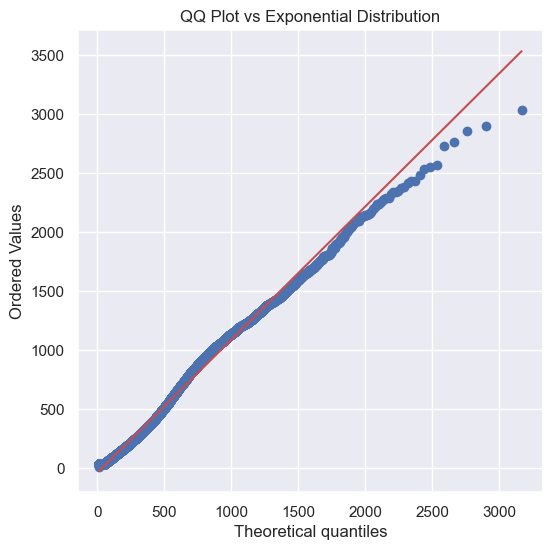

In [277]:
print(df['avg_time_spent'].describe())
from scipy.stats import probplot, expon

loc, scale = expon.fit(df['avg_time_spent'].dropna())

# QQ Plot
plt.figure(figsize=(6, 6))
probplot(df['avg_time_spent'].dropna(), dist="expon", sparams=(loc, scale), plot=plt)
plt.title('QQ Plot vs Exponential Distribution')
plt.show()

We can see that the column data looks fairly similar to exponential distribution except at the right end (probably due to making values absolute)

### <a id='toc1_2_3_'></a>[avg_transaction_value](#toc0_)

In [278]:
df['avg_transaction_value'].head(15)

0     10579.56
1     22963.05
2     32604.41
3     48913.61
4     20010.02
5     48040.07
6     30913.21
7     29838.99
8     68499.01
9     42054.69
10    83958.21
11    11660.05
12    30385.72
13    34016.27
14    97583.94
Name: avg_transaction_value, dtype: float64

Drop-off happens around: 49366.119099999996


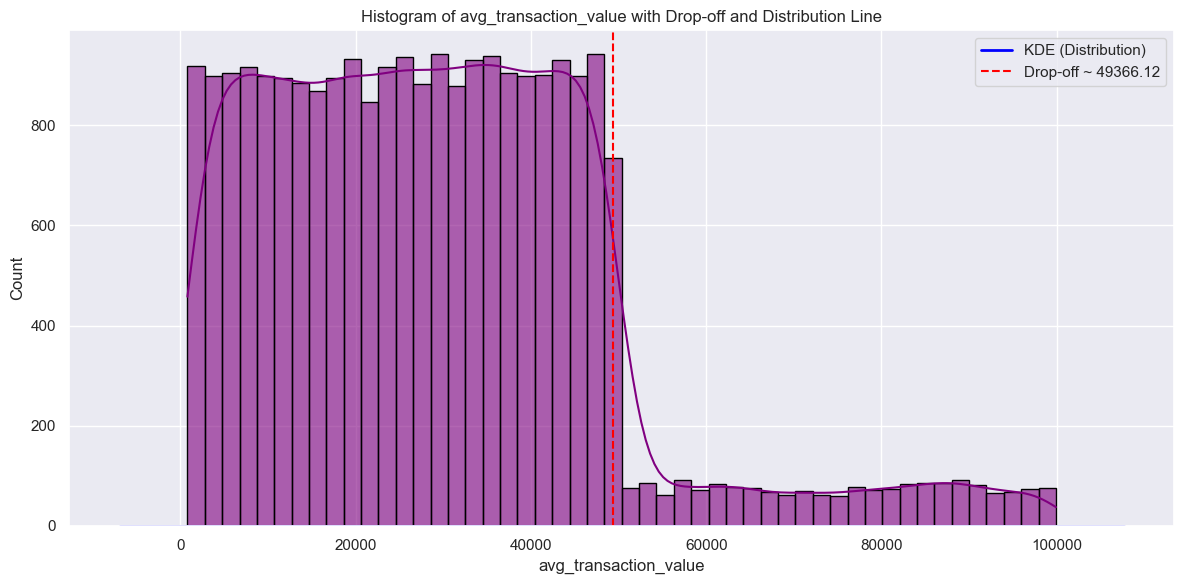

In [279]:
# 1. Create histogram and calculate counts in bins
counts, bins = np.histogram(df['avg_transaction_value'].dropna(), bins=50)

# 2. Calculate the bin centers (middle points of each bin)
bin_centers = (bins[:-1] + bins[1:]) / 2

# 3. Calculate the rate of change (diff) in counts between adjacent bins
rate_of_change = np.diff(counts)

# 4. Identify where the drop-off occurs
dropoff_index = np.argmax(rate_of_change < -500)  # adjust threshold if needed
dropoff_value = bin_centers[dropoff_index]
print(f'Drop-off happens around: {dropoff_value}')

# 5. Plot only once (histogram + mark drop-off + distribution line)
plt.figure(figsize=(12, 6))

# Plot histogram
sns.histplot(df['avg_transaction_value'], bins=50, kde=True, color='purple', edgecolor='black', alpha=0.6)

# Add KDE line (distribution line)
sns.kdeplot(df['avg_transaction_value'].dropna(), color='blue', linewidth=2, label='KDE (Distribution)')

# Add drop-off point line
plt.axvline(dropoff_value, color='red', linestyle='--', label=f'Drop-off ~ {dropoff_value:.2f}')

# Titles and labels
plt.title('Histogram of avg_transaction_value with Drop-off and Distribution Line')
plt.xlabel('avg_transaction_value')
plt.ylabel('Count')
plt.legend()

# Display plot
plt.tight_layout()
plt.show()


We can see many more people spend on average less than 50,000

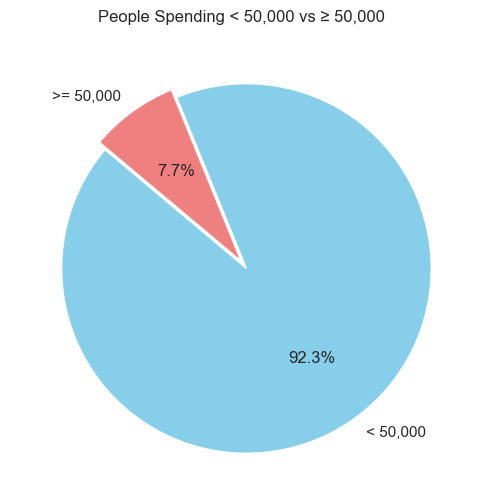

In [280]:
# 1. Count people in each group
below_50k = (df['avg_transaction_value'] < 50000).sum()
above_or_equal_50k = (df['avg_transaction_value'] >= 50000).sum()

# 2. Prepare data for pie chart
counts = [below_50k, above_or_equal_50k]
labels = ['< 50,000', '>= 50,000']
colors = ['skyblue', 'lightcoral']

# 3. Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.05, 0))
plt.title('People Spending < 50,000 vs ≥ 50,000')
plt.show()

Now we can check statistics for each group

Descriptive statistics for < 50,000 group:
count    22480.000000
mean     25467.862160
std      14217.896139
min        800.460000
25%      13066.517500
50%      25562.590000
75%      37728.212500
max      49997.690000
Name: avg_transaction_value, dtype: float64

Descriptive statistics for >= 50,000 group:
count     1885.000000
mean     75022.854218
std      14541.701695
min      50012.940000
25%      62052.540000
50%      75461.870000
75%      87563.690000
max      99914.050000
Name: avg_transaction_value, dtype: float64


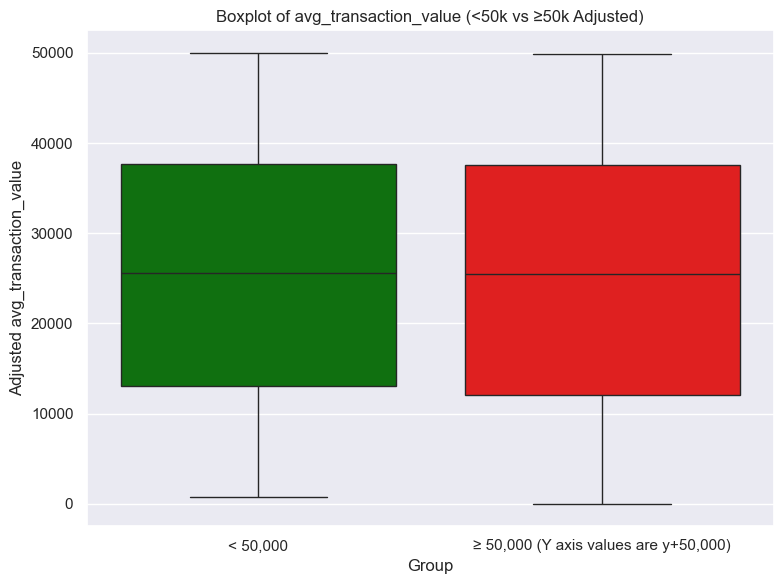

In [281]:
# 1. Split into two groups
below_50k = df[df['avg_transaction_value'] < 50000]['avg_transaction_value']
above_50k = df[df['avg_transaction_value'] >= 50000]['avg_transaction_value']

# 2. Describe both groups
print("Descriptive statistics for < 50,000 group:")
print(below_50k.describe())
print("\nDescriptive statistics for >= 50,000 group:")
print(above_50k.describe())

# 1. Split into two groups
below_50k = df[df['avg_transaction_value'] < 50000]['avg_transaction_value']
above_50k = df[df['avg_transaction_value'] >= 50000]['avg_transaction_value'] - 50000  # Adjusted values

# 2. Prepare data for seaborn boxplot
boxplot_df = pd.DataFrame({
    'avg_transaction_value': pd.concat([below_50k, above_50k]),
    'Group': (['< 50,000'] * len(below_50k)) + (['≥ 50,000 (Y axis values are y+50,000)'] * len(above_50k))
})

# 3. Plot boxplots with adjusted values for the ≥50k group
plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='avg_transaction_value', data=boxplot_df, hue='Group', 
            palette=['green', 'red'], legend=False)
plt.title('Boxplot of avg_transaction_value (<50k vs ≥50k Adjusted)')
plt.xlabel('Group')
plt.ylabel('Adjusted avg_transaction_value')
plt.tight_layout()
plt.show()

We can see that relatively for each group they are distributed in a similar manner

### <a id='toc1_2_4_'></a>[days_since_last_login](#toc0_)

In [282]:
df['days_since_last_login'].head(15)

0     20
1     15
2     23
3      7
4     10
5     14
6     13
7     12
8     13
9     13
10     8
11    14
12    20
13    14
14     6
Name: days_since_last_login, dtype: int64

In [283]:
print(df['days_since_last_login'].describe())
print("The skewness is: ", df['days_since_last_login'].skew())

count    24365.000000
mean       -42.539709
std        229.985746
min       -999.000000
25%          8.000000
50%         12.000000
75%         16.000000
max         26.000000
Name: days_since_last_login, dtype: float64
The skewness is:  -3.9162117166272137


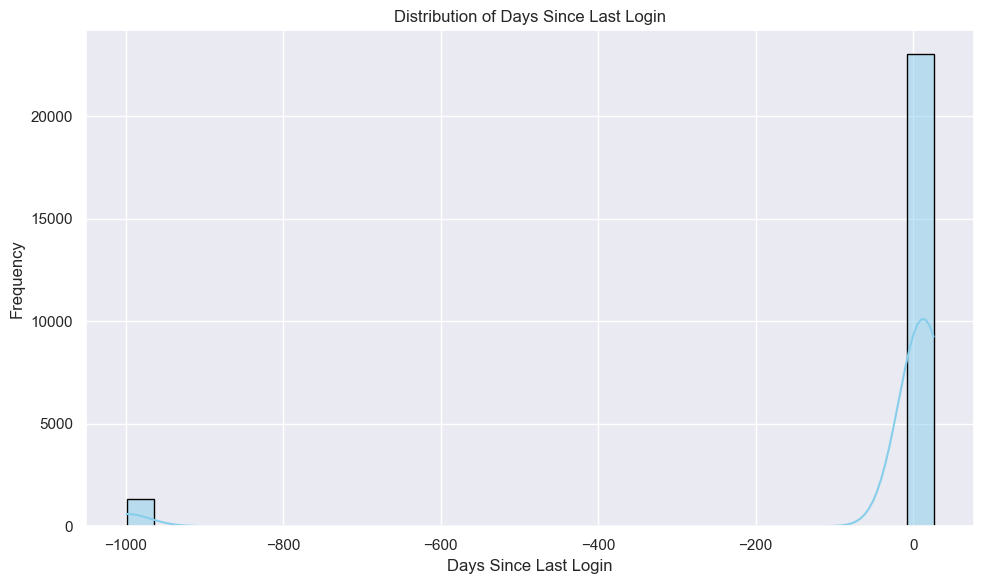

Number of negative values:  1331


In [284]:
plt.figure(figsize=(10, 6))
sns.histplot(df['days_since_last_login'].dropna(), bins=30, kde=True, color='skyblue', edgecolor='black')

plt.title('Distribution of Days Since Last Login')
plt.xlabel('Days Since Last Login')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

numNegative = (df['days_since_last_login'] < 0).sum()
print("Number of negative values: ", numNegative)

It seems that the negative values are a mistake. We will make them null

Summary of 'days_since_last_login':
- Minimum value: 1.0
- Maximum value: 26.0
- Mean value: 12.728531735695059
- Median value: 13.0
- Standard Deviation: 5.576306115968179
Skewness of 'days_since_last_login': 0.0345


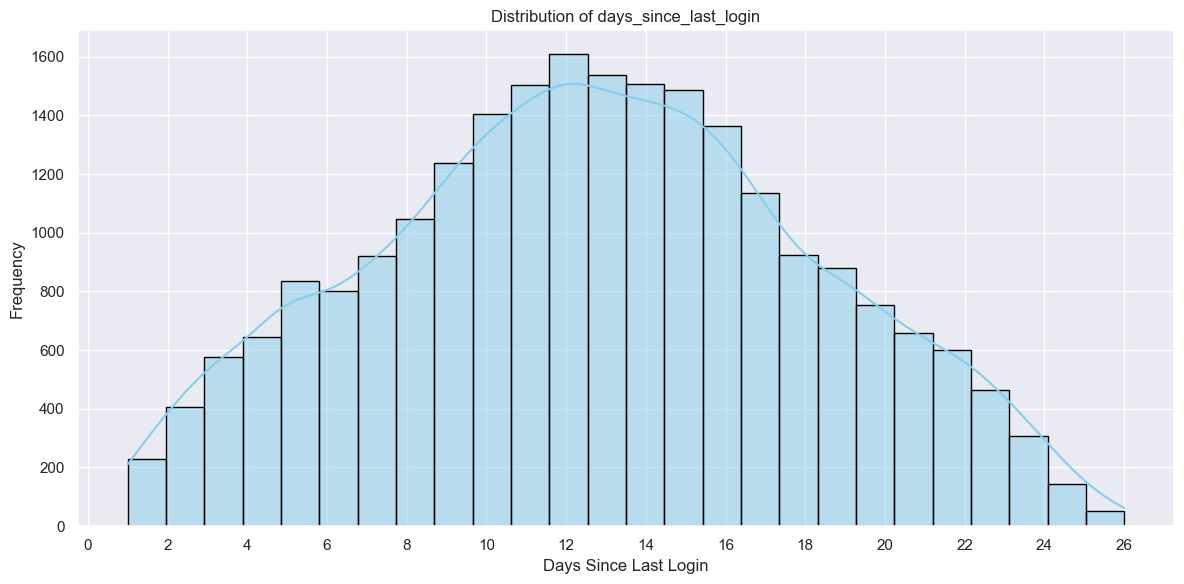

In [285]:

# Ensure 'days_since_last_login' is numeric
df['days_since_last_login'] = pd.to_numeric(df['days_since_last_login'], errors='coerce')

# Replace negative values with NaN
df.loc[df['days_since_last_login'] < 0, 'days_since_last_login'] = np.nan


# Drop NaNs for safe analysis
days_data = df['days_since_last_login'].dropna()

# Calculate statistics
min_val = days_data.min()
max_val = days_data.max()
mean_val = days_data.mean()
median_val = days_data.median()
std_val = days_data.std()

# Print statistics
print(f"Summary of 'days_since_last_login':")
print(f"- Minimum value: {min_val}")
print(f"- Maximum value: {max_val}")
print(f"- Mean value: {mean_val}")
print(f"- Median value: {median_val}")
print(f"- Standard Deviation: {std_val}")

# Calculate skewness for 'days_since_last_login' column
skewness_days_since_last_login = days_data.skew()

print(f"Skewness of 'days_since_last_login': {skewness_days_since_last_login:.4f}")

# Plot distribution
plt.figure(figsize=(12, 6))
sns.histplot(days_data, bins=26, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of days_since_last_login')
plt.xticks(range(0, 27, 2))
plt.xlabel('Days Since Last Login')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


It seems like column is distributed according to normal distribution. Changing the null values to values according to distribution

In [286]:
# 1. Select the non-null values
non_null_values = df['days_since_last_login'].dropna()

# 2. Find how many nulls we have
num_nulls = df['days_since_last_login'].isnull().sum()

print(f"Number of nulls to impute: {num_nulls}")

# 3. Randomly sample from existing (non-null) values, with replacement
imputed_values = np.random.choice(non_null_values, size=num_nulls, replace=True)

# 4. Fill nulls with the sampled values
df.loc[df['days_since_last_login'].isnull(), 'days_since_last_login'] = imputed_values


Number of nulls to impute: 1331


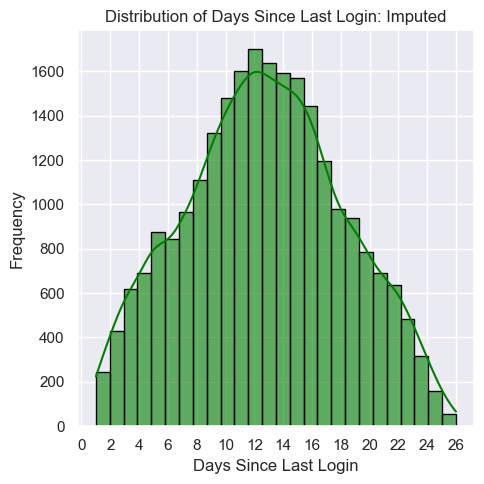

count    24365.000000
mean        12.719146
std          5.573405
min          1.000000
25%          9.000000
50%         13.000000
75%         17.000000
max         26.000000
Name: days_since_last_login, dtype: float64


In [287]:
# Plot imputed data (after imputation)
sns.histplot(df['days_since_last_login'], bins=26, kde=True, color='green', edgecolor='black', label='Imputed Data', alpha=0.6)

plt.title('Distribution of Days Since Last Login: Imputed')
plt.xticks(range(0, 27, 2))
plt.xlabel('Days Since Last Login')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

print(df['days_since_last_login'].describe())

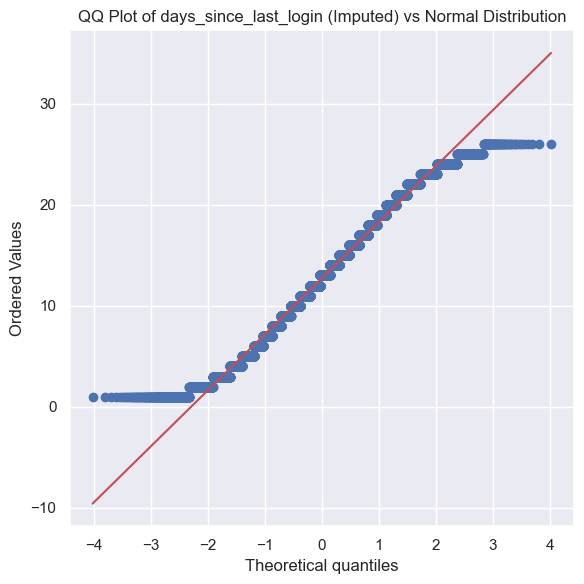

In [288]:
import scipy.stats as stats

# QQ plot for imputed data vs Normal distribution
plt.figure(figsize=(6, 6))
stats.probplot(df['days_since_last_login'].dropna(), dist="norm", plot=plt)
plt.title('QQ Plot of days_since_last_login (Imputed) vs Normal Distribution')
plt.grid(True)
plt.tight_layout()
plt.show()

The data seems to be normally distributed in the middle but not on the edges

### <a id='toc1_2_5_'></a>[points_in_wallet](#toc0_)

In [289]:
print(df['points_in_wallet'].describe())


count    22283.000000
mean       686.290747
std        193.095242
min       -549.357498
25%        616.295000
50%        696.910000
75%        763.130000
max       1816.933696
Name: points_in_wallet, dtype: float64


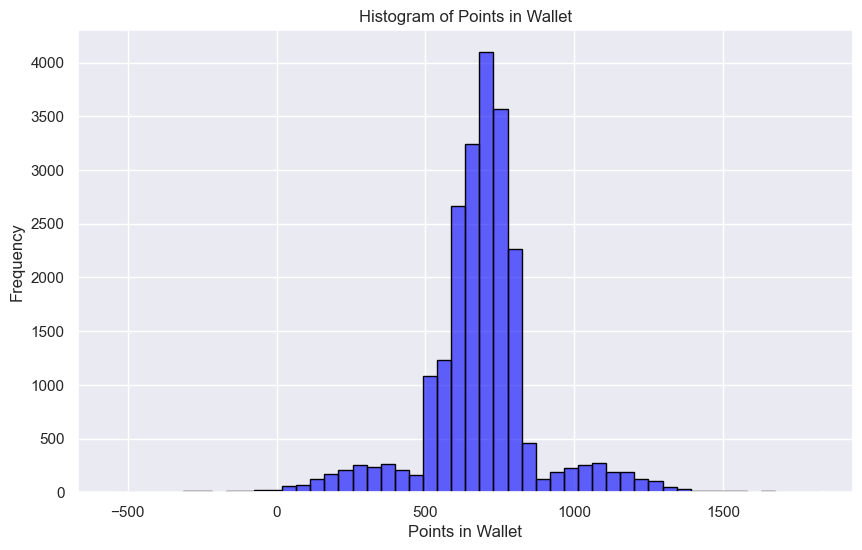

In [290]:
# Plot the histogram of the data
plt.figure(figsize=(10, 6))
sns.histplot(df['points_in_wallet'], bins=50, kde=False, color='blue', edgecolor='black', alpha=0.6)

# Set plot titles and labels
plt.title('Histogram of Points in Wallet')
plt.xlabel('Points in Wallet')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


We can see that the distribution is fairly simmetrical

In [291]:
(df['points_in_wallet'] < 0).sum()


np.int64(89)

We assume that are null and negative values are because of user not making a purchase and therefore we will replace these values with 0

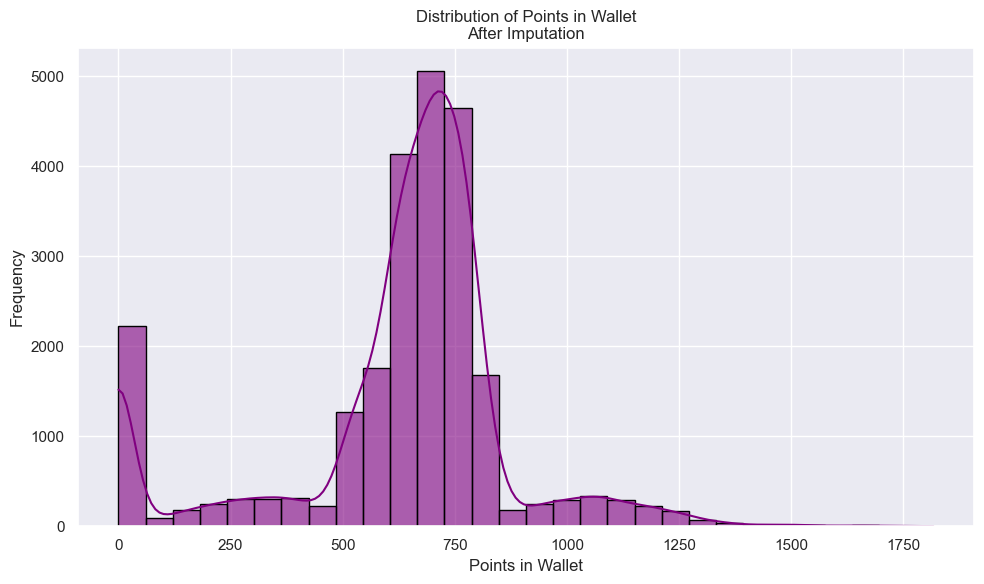

In [292]:

# Replace NaN and negative values in 'points_in_wallet' with 0
df['points_in_wallet'] = df['points_in_wallet'].apply(lambda x: 0 if pd.isnull(x) or x < 0 else x)

# Plot distribution for 'points_in_wallet' after imputation
plt.figure(figsize=(10, 6))
sns.histplot(df['points_in_wallet'], bins=30, kde=True, color='purple', edgecolor='black', alpha=0.6)
plt.title('Distribution of Points in Wallet\nAfter Imputation')
plt.xlabel('Points in Wallet')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

Now we can create correlation matrix to try and see what correlations there may be

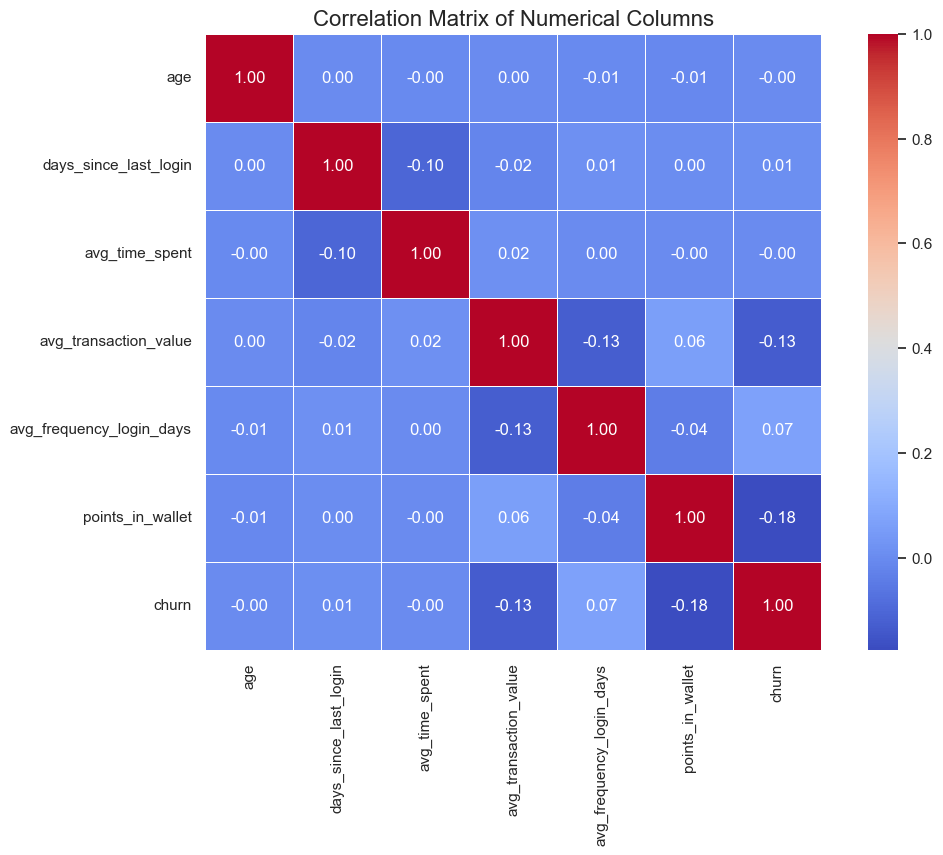

In [293]:
# Select only numerical columns
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Compute the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 8))  # Adjust the size of the figure
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Columns', fontsize=16)
plt.show()

We can see that there isn't much correlation between two columns. At most correlation between churn and points_in_wallet and between churn and avg_transaction_value

## <a id='toc1_3_'></a>[Categorical Columns](#toc0_)

In [294]:
# Iterate over categorical columns, excluding 'referral_id'
for column in [col for col in categorical_columns if col != 'referral_id']:
    unique_vals = df[column].dropna().unique()  # Get unique values, excluding NaNs
    if len(unique_vals) < 10:  # Check if the number of unique values is less than 10
        print(f"Column: {column}")
        print(f"Unique values: {unique_vals}")
        print("-" * 50)

Column: churn
Unique values: [1 0]
--------------------------------------------------
Column: complaint_status
Unique values: ['Not Applicable' 'No Information Available' 'Unsolved'
 'Solved in Follow-up' 'Solved']
--------------------------------------------------
Column: feedback
Unique values: ['Poor Product Quality' 'Too many ads' 'No reason specified'
 'Products always in Stock' 'Poor Customer Service' 'Reasonable Price'
 'User Friendly Website' 'Poor Website' 'Quality Customer Care']
--------------------------------------------------
Column: gender
Unique values: ['F' 'M' 'Unknown']
--------------------------------------------------
Column: internet_option
Unique values: ['Mobile_Data' 'Wi-Fi' 'Fiber_Optic']
--------------------------------------------------
Column: joined_through_referral
Unique values: ['Yes' 'No']
--------------------------------------------------
Column: medium_of_operation
Unique values: ['Desktop' 'Smartphone' 'Both']
---------------------------------------

Now for each column we will check for null, then see the distribution of values and then deal with problematic values or other issues which may be cleared up.

### gender

In [295]:
df['gender'].value_counts()

gender
F          12244
M          12081
Unknown       40
Name: count, dtype: int64

_Replace 'unknown' values in the 'gender' column with the most frequent value ('female') to handle missing data:_

In [296]:
df['gender'] = df['gender'].replace('Unknown', 'F')

In [297]:
df['gender'].value_counts()

gender
F    12284
M    12081
Name: count, dtype: int64

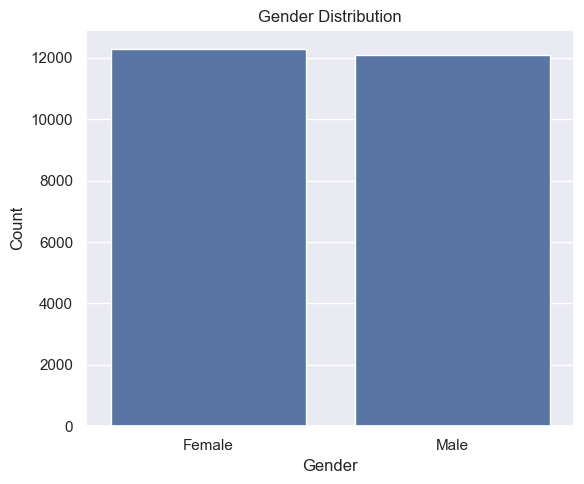

In [298]:
# Map gender values to more descriptive labels
df['gender'] = df['gender'].map({'F': 'Female', 'M': 'Male'})

# Plot bar chart for gender distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### region_category

_Plot the distribution of 'region_category' before filling missing values, including NaN values_


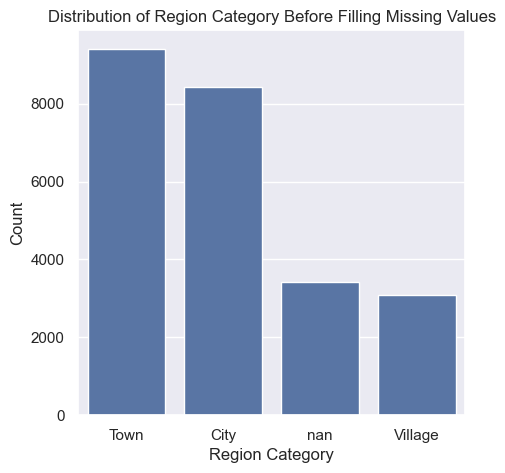

In [299]:
# Count the occurrences (including NaN as a separate row)
region_counts_before = df['region_category'].value_counts(dropna=False)

# Plotting a bar chart
sns.barplot(x=region_counts_before.index.astype(str), y=region_counts_before.values)
plt.title('Distribution of Region Category Before Filling Missing Values')
plt.ylabel('Count')
plt.xlabel('Region Category')
plt.show()

 _Fill missing values in 'region_category' by randomly assigning 'Town', 'City', or 'Village' based on their existing distribution:_


In [300]:
# Define the probabilities based on the existing distribution
probs = {
    'Town': 9476 / (9476 + 8495 + 3116),
    'City': 8495 / (9476 + 8495 + 3116),
    'Village': 3116 / (9476 + 8495 + 3116)
}

# Find the indices of missing values in the 'region_category' column
missing_indices = df[df['region_category'].isnull()].index

# Randomly assign 'Town', 'City', or 'Village' to missing values based on the calculated probabilities
df.loc[missing_indices, 'region_category'] = np.random.choice(
    ['Town', 'City', 'Village'],
    size=len(missing_indices),
    p=[probs['Town'], probs['City'], probs['Village']]
)

_checking the changes:_

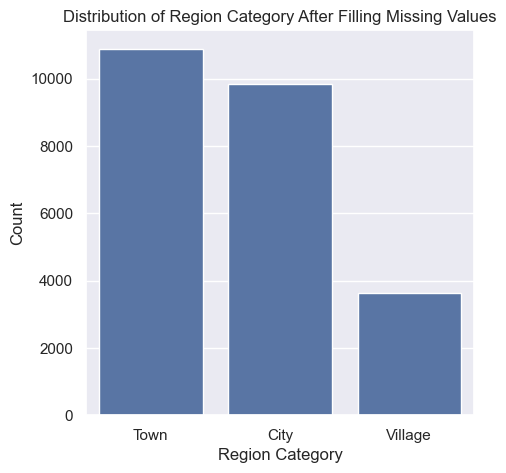

In [301]:
# Count the occurrences of each value in the 'region_category' column
region_counts = df['region_category'].value_counts()

# Plotting the distribution of 'region_category'
sns.barplot(x=region_counts.index, y=region_counts.values)
plt.title('Distribution of Region Category After Filling Missing Values')
plt.ylabel('Count')
plt.xlabel('Region Category')
plt.show()

In [302]:
df['region_category'].isnull().sum()

np.int64(0)

### membership_category

In [303]:
df['membership_category'].isnull().sum()

np.int64(0)

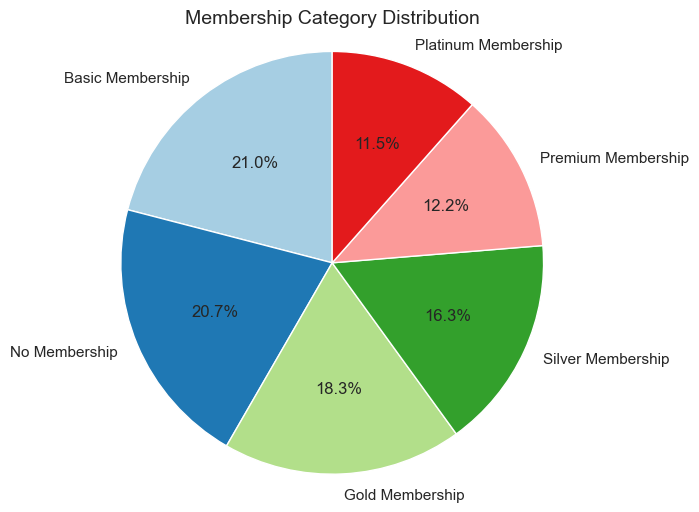

In [304]:
# Count values
membership_counts = df['membership_category'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(membership_counts, labels=membership_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Membership Category Distribution', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

### joined_through_referral and referral_id

In [305]:
df['joined_through_referral'].value_counts()

joined_through_referral
No     10589
Yes    10426
Name: count, dtype: int64

In [306]:
df['joined_through_referral'].isnull().sum()

np.int64(3350)

In [307]:
df['referral_id'].isnull().sum()

np.int64(11905)

In [308]:
df['referral_id'].notna().sum()

np.int64(12460)

We observe that the _joined_through_referral_ column contains:
- 10,426 values marked as **Yes**
- 10,589 values marked as **No**
- 3,350 are **null**

And that the _referral_id_ column contains:
- 11,905 are **null**
- 12,460 are **not null**

From this, we can infer the following:

- There should be 10,589 + 3350 = **13,939 missing values in the _referral_id_ column**, corresponding to users who were **not referred** and **10,426 non-missing values**, corresponding to users who were **referred**.
- There should **not be a _referral_id_** for anyone who:
  - Was **not referred** (_joined_through_referral_ = No)
  - **Did not answer** whether they were referred
- Conversely, for users who answered **Yes** (i.e., they were referred), we **expect a _referral_id_ value to exist**, since someone referred them and that referrer must have a unique ID.


_The following code checks whether there are any users who answered "Yes" in the _joined_through_referral_ column but have a missing value in the _referral_id_ column. Such cases would indicate data inconsistency._

In [309]:
# Filter users who answered 'Yes' to being referred
referred_yes = df[df['joined_through_referral'] == 'Yes']
# Check how many of them have a missing referral_id
missing_referral_id = referred_yes['referral_id'].isna().sum()
# Print the number of inconsistent rows
print(f"Number of users who said 'Yes' but have missing referral_id: {missing_referral_id}")

Number of users who said 'Yes' but have missing referral_id: 961


_The following code checks whether all users who answered "No" in the _joined_through_referral_ column have a missing value in the _referral_id_ column. If any of them have a non-missing value, it may indicate data inconsistency._

In [310]:
# Filter users who answered 'No' to being referred
referred_no = df[df['joined_through_referral'] == 'No']
# Check how many of them have a non-missing referral_id (this should be zero)
non_missing_referral_id = referred_no['referral_id'].notna().sum()
# Print the number of inconsistent rows
print(f"Number of users who said 'No' but have referral_id: {non_missing_referral_id}")

Number of users who said 'No' but have referral_id: 0


_The following code checks how many users who did not respond to the _joined_through_referral_ question (i.e., missing values) also have a missing value in the _referral_id_ column. These cases are expected, as referral_id should be absent if the referral status is unknown._

In [311]:
# Filter users with missing response in 'joined_through_referral'
no_response = df[df['joined_through_referral'].isna()]
# Count how many of them have a missing referral_id
missing_referral_id = no_response['referral_id'].isna().sum()
# Print the result
print(f"Number of users with no response to 'joined_through_referral' and missing 'referral_id': {missing_referral_id}")

Number of users with no response to 'joined_through_referral' and missing 'referral_id': 355


_The following code checks how many users who did not respond to the _joined_through_referral_ question still have a value in the _referral_id_ column. These cases are unexpected and may indicate a data inconsistency._

In [312]:
# Filter users with missing response in 'joined_through_referral'
no_response = df[df['joined_through_referral'].isna()]
# Count how many of them have a non-missing referral_id (unexpected)
has_referral_id = no_response['referral_id'].notna().sum()
# Print the result
print(f"Number of users with no response to 'joined_through_referral' but have a referral_id: {has_referral_id}")

Number of users with no response to 'joined_through_referral' but have a referral_id: 2995


_The following code checks how many users who answered "No" in the _joined_through_referral_ column have a missing value in the _referral_id_ column. These cases are expected and consistent with the logic that non-referred users should not have a referral ID._

In [313]:
# Filter users who answered 'No' to being referred
referred_no = df[df['joined_through_referral'] == 'No']
# Count how many of them have a missing referral_id (expected)
missing_referral_id = referred_no['referral_id'].isna().sum()
# Print the result
print(f"Number of users who said 'No' and have missing referral_id: {missing_referral_id}")

Number of users who said 'No' and have missing referral_id: 10589


Conclusions so far:

- For all castomers who has **"No"** in the _joined_through_referral_ column, the values in the _referral_id_ column are **all missing**.  
    This is good, as it matches the expected logic that non-referred customers should not have a referral ID.

- Among the customers who has **"Yes"**, there are **968 missing values** in the _referral_id_ column.  
    This is unexpected, since referred customers should have a valid referral ID.

- Among customers who has **missing answer** to whether they were referred, there are **hundreds missing values** in the _referral_id_ column, while there are **around 3 thousand missing values** in the _joined_through_referral_ column overall.
    This means that **around 3 thousand customers** have a _referral_id_ even though they did not answer the referral question.  
     This is a potential inconsistency in the data and may indicate a problem with data collection or input.

  #### Decision to Drop the _referral_id_ Column

Although the dataset includes a _referral_id_ column, intended to track who referred each customer, the data is incomplete and inconsistent. Specifically, many customers who were marked as referred (_joined_through_referral_ = "Yes") have missing referral IDs, and some customers with unknown referral status still have referral IDs.

Since our main goal is to analyze customer retention and understand why users choose to stay or leave, and because the _joined_through_referral_ column already captures the relevant information in a cleaner, more reliable format, we decided to drop the _referral_id_ column from the analysis. 
This allows us to simplify the dataset and focus on features that are more meaningful and consistent.

<br>
We also assume that missing values in joined_through_refferal mean that nothing was entered and therefore the customer did not join through a referral and therefore we will change missing values to No



In [314]:
df.drop(columns=['referral_id'], inplace=True)

In [315]:
df['joined_through_referral'] = df['joined_through_referral'].fillna('No')
df['joined_through_referral'].value_counts()

joined_through_referral
No     13939
Yes    10426
Name: count, dtype: int64

In [316]:
pd.set_option('display.max_columns', None)
df.head()

,customer_id,Name,age,gender,region_category,membership_category,joining_date,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn
0,fffe43004900440033003200390032003400,Dusty Dunneback,30,Female,Village,No Membership,2017-08-09,Yes,Gift Vouchers/Coupons,Desktop,Mobile_Data,20.0,118.390000,10579.56,24.0,610.360000,Yes,No,No,Not Applicable,Poor Product Quality,1
1,fffe43004900440036003200310038003600,Dorine Vanduyn,55,Male,Village,Silver Membership,2016-02-09,No,Credit/Debit Card Offers,Smartphone,Wi-Fi,15.0,179.420000,22963.05,27.0,694.650000,Yes,No,No,Not Applicable,Poor Product Quality,0
2,fffe430049004400350032003200,Christene Pulver,47,Male,City,Basic Membership,2017-06-11,Yes,Credit/Debit Card Offers,NaN,Wi-Fi,23.0,42.230000,32604.41,17.0,520.620000,Yes,No,No,Not Applicable,Poor Product Quality,1
3,fffe43004900440032003200380034003600,Brendan Enciso,18,Male,Town,Gold Membership,2016-02-09,No,Credit/Debit Card Offers,Desktop,Mobile_Data,7.0,1035.833706,48913.61,27.0,1150.093442,Yes,No,No,Not Applicable,Too many ads,0
4,fffe43004900440035003600320032003100,Lizette Lemons,28,Female,City,No Membership,2017-07-16,Yes,Credit/Debit Card Offers,Both,Fiber_Optic,10.0,449.770000,20010.02,14.0,653.040000,Yes,Yes,Yes,No Information Available,No reason specified,0


### preferred_offer_types

In [317]:
df['preferred_offer_types'].value_counts()

preferred_offer_types
Gift Vouchers/Coupons       8162
Credit/Debit Card Offers    8120
Without Offers              7909
Name: count, dtype: int64

In [318]:
df['preferred_offer_types'].isnull().sum()

np.int64(174)

_We handle the 174 missing values in the 'preferred_offer_types' column by filling them according to the existing distribution of values.  
This approach helps maintain the natural balance of the data without introducing bias:_

In [319]:
df['preferred_offer_types'] = df['preferred_offer_types'].fillna(
    pd.Series(np.random.choice(
        df['preferred_offer_types'].dropna().unique(), 
        size=df['preferred_offer_types'].isnull().sum(), 
        p=df['preferred_offer_types'].value_counts(normalize=True)
    ), index=df[df['preferred_offer_types'].isnull()].index)
)

In [320]:
df['preferred_offer_types'].value_counts()

preferred_offer_types
Gift Vouchers/Coupons       8218
Credit/Debit Card Offers    8178
Without Offers              7969
Name: count, dtype: int64

In [321]:
df['preferred_offer_types'].isnull().sum()

np.int64(0)

Analysis of Preferred Offer Types by Membership Category


_This heatmap visually displays how different membership categories are associated with preferred offer types. Darker colors indicate higher frequency of customers in that combination:_

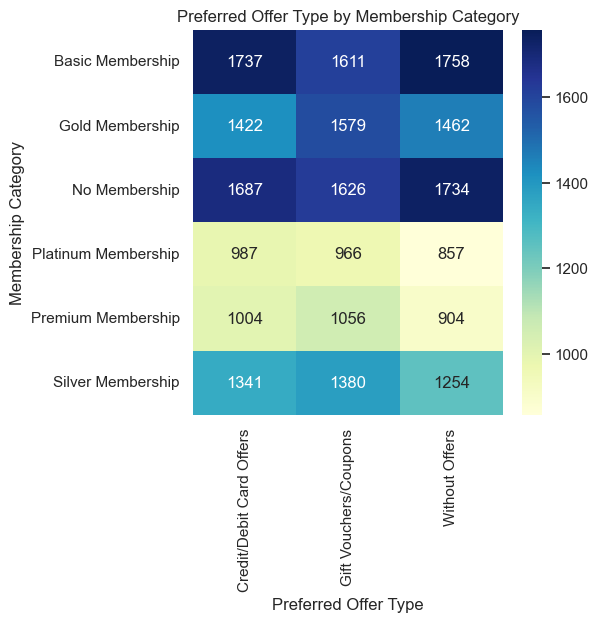

In [322]:
# Plot a heatmap to visualize the relationship between membership and preferred offer type
offer_membership_ct = pd.crosstab(df['membership_category'], df['preferred_offer_types'])
sns.heatmap(offer_membership_ct, annot=True, fmt='d', cmap='YlGnBu')

# Add title and axis labels
plt.title('Preferred Offer Type by Membership Category')
plt.xlabel('Preferred Offer Type')
plt.ylabel('Membership Category')

plt.show()

Key Insights:
- **Customers with No Membership or Basic Membership generally prefer offers:**
  - These groups show the highest counts across all three offer types.
  - This may suggest that they are more promotion-sensitive or value-oriented.
- **Customers with Premium or Platinum Membership show lower interest in offers:**
  - These tiers have noticeably fewer customers selecting offers.
  - Especially in the Platinum group, the preference for offers is lowest—possibly due to existing perks included in their membership.
- **No strong preference for a specific offer type within most membership tiers:**
  - For instance, in the Gold Membership category, the distribution is fairly even among all three offer types.
Possible Interpretation:
- Lower-tier members (e.g., Basic, No Membership) may actively seek discounts or added value through offers.
- Higher-tier members (e.g., Premium, Platinum) may already feel they are receiving benefits, making external offers less appealing.



### medium_of_operation

In [323]:
print("Number of Null:", df['medium_of_operation'].isna().sum())

Number of Null: 3339


That is a lot of Null values, so we cannot delete them, and it is better not to imput values with distribution of the rest.<br>
We will just make them all Unknown

In [324]:
df['medium_of_operation'] = df['medium_of_operation'].fillna('Unknown')
print("Number of Null:", df['medium_of_operation'].isna().sum())

Number of Null: 0


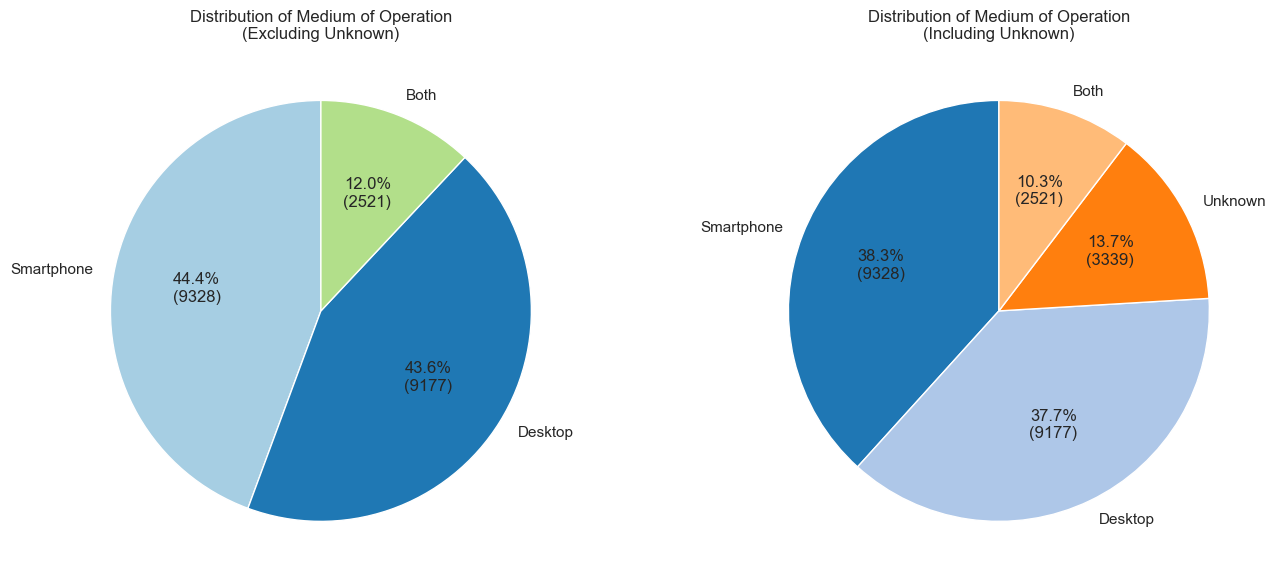

In [325]:
# Count values including 'Unknown'
value_counts = df['medium_of_operation'].value_counts()

# Count values excluding 'Unknown'
value_counts_no_unknown = df[df['medium_of_operation'] != 'Unknown']['medium_of_operation'].value_counts()

# Function to format labels as percentage + count
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count})'
    return my_autopct

# Create figure with 2 subplots (only pie charts)
plt.figure(figsize=(14, 6))

# 1st subplot: Pie chart (excluding 'Unknown')
plt.subplot(1, 2, 1)
plt.pie(value_counts_no_unknown, 
        labels=value_counts_no_unknown.index, 
        autopct=make_autopct(value_counts_no_unknown), 
        startangle=90, 
        colors=plt.cm.Paired.colors)
plt.title('Distribution of Medium of Operation\n(Excluding Unknown)')

# 2nd subplot: Pie chart (including 'Unknown')
plt.subplot(1, 2, 2)
plt.pie(value_counts, 
        labels=value_counts.index, 
        autopct=make_autopct(value_counts), 
        startangle=90, 
        colors=plt.cm.tab20.colors)
plt.title('Distribution of Medium of Operation\n(Including Unknown)')

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

Now we will check how each category might have an effect on target feature 'churn'.

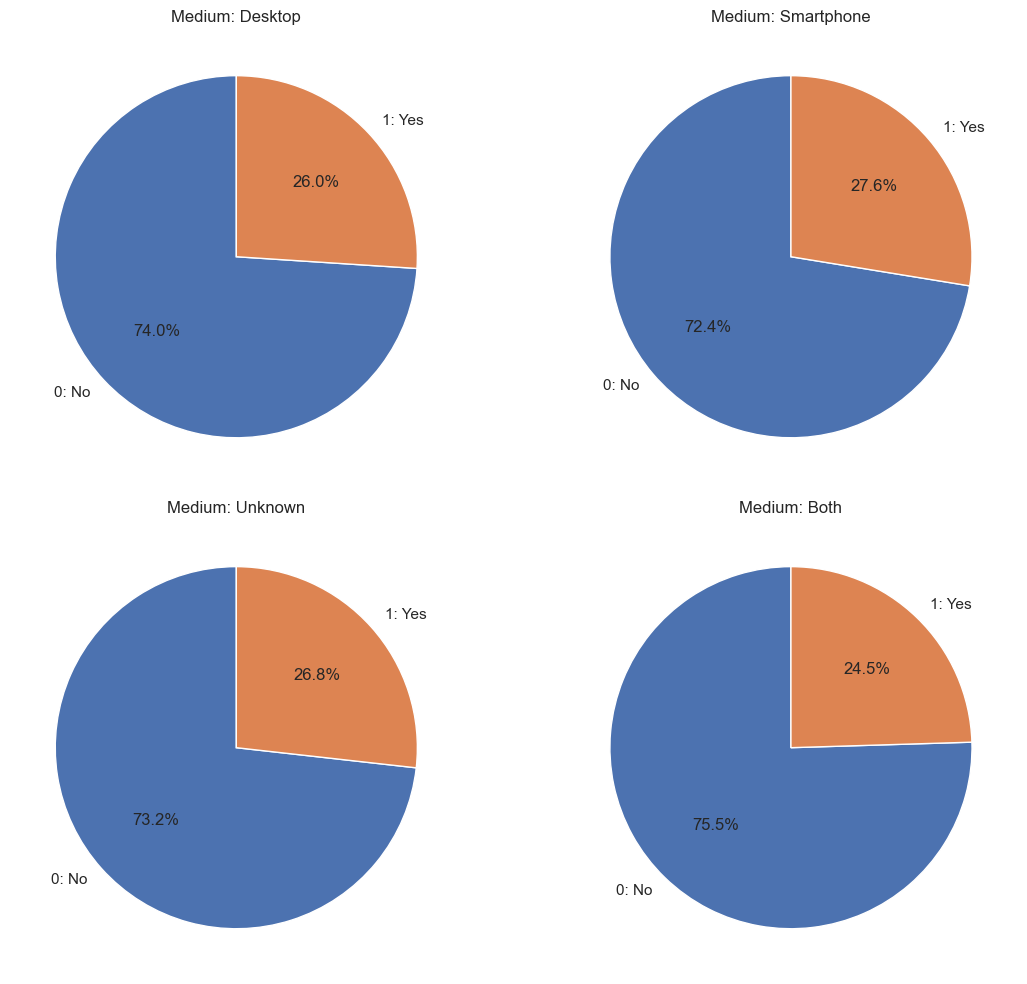

In [326]:

# Combine the two DataFrames if they align row-wise
data_df1 = pd.concat([df['medium_of_operation'], df['churn']], axis=1)

# Get unique mediums
mediums = data_df1['medium_of_operation'].unique()

# Set up a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten to easily index

for i, medium in enumerate(mediums[:4]):  # Only plot up to 4 mediums
    subset = data_df1[data_df1['medium_of_operation'] == medium]
    churn_counts = subset['churn'].value_counts()
    
    axes[i].pie(
        churn_counts, 
        labels=churn_counts.index.map({0: '0: No', 1: '1: Yes'}), 
        autopct='%1.1f%%', 
        startangle=90
    )
    axes[i].set_title(f'Medium: {medium}')

# Hide any unused subplots (in case mediums < 4)
for j in range(len(mediums), 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

It seems that the distribution of churn is similar for all groups of medium_of_operation. <br>
This might change for more complicated patterns

### internet_option


In [327]:
print("Number of Null:", df['internet_option'].isna().sum())

Number of Null: 0


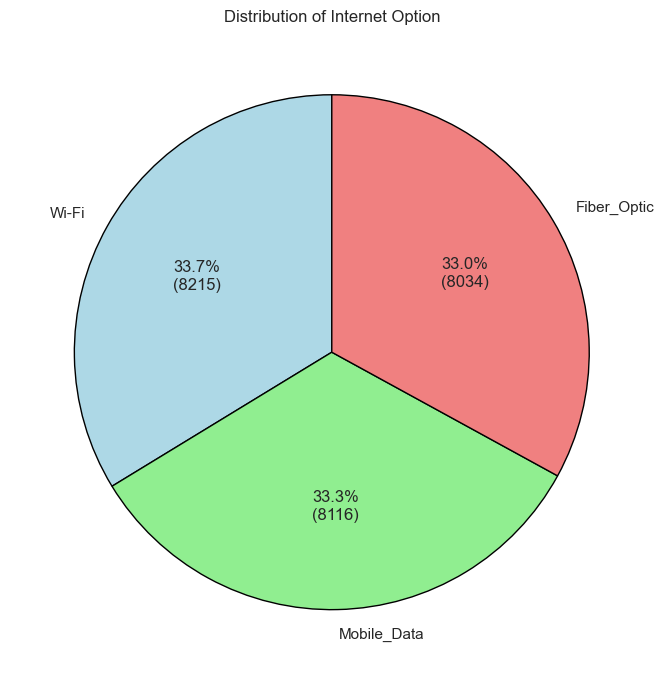

In [328]:
# Count values
value_counts = df['internet_option'].value_counts()

# Function to format labels as percentage + count (on separate lines)
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count})'  # <-- \n makes count go under percentage
    return my_autopct

# Create the pie chart
plt.figure(figsize=(7, 7))
plt.pie(value_counts, 
        labels=value_counts.index, 
        autopct=make_autopct(value_counts), 
        colors=['lightblue', 'lightgreen', 'lightcoral', 'gold'], 
        startangle=90, 
        wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Internet Option')

plt.tight_layout()
plt.show()

### used_special_discount         


In [329]:
print("Number of Null:", df['used_special_discount'].isna().sum())

Number of Null: 0


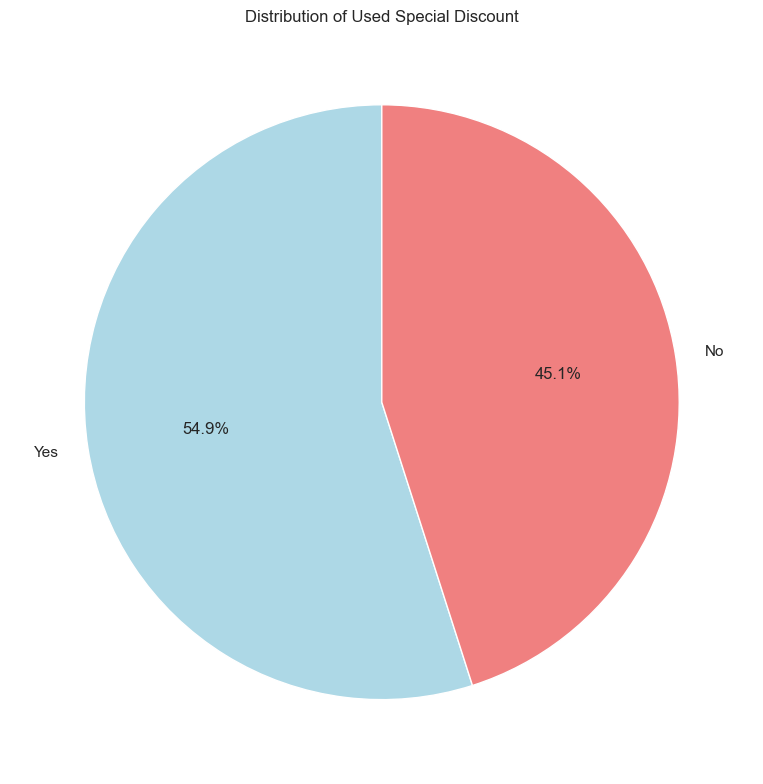

In [330]:
# 1. Count the occurrences of each unique value in 'used_special_discount'
discount_counts = df['used_special_discount'].value_counts()

# 2. Pie chart for the distribution of values in 'used_special_discount'
plt.figure(figsize=(8, 8))
discount_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
plt.title('Distribution of Used Special Discount')
plt.ylabel('')  # Hide the y-label for clarity
plt.tight_layout()
plt.show()


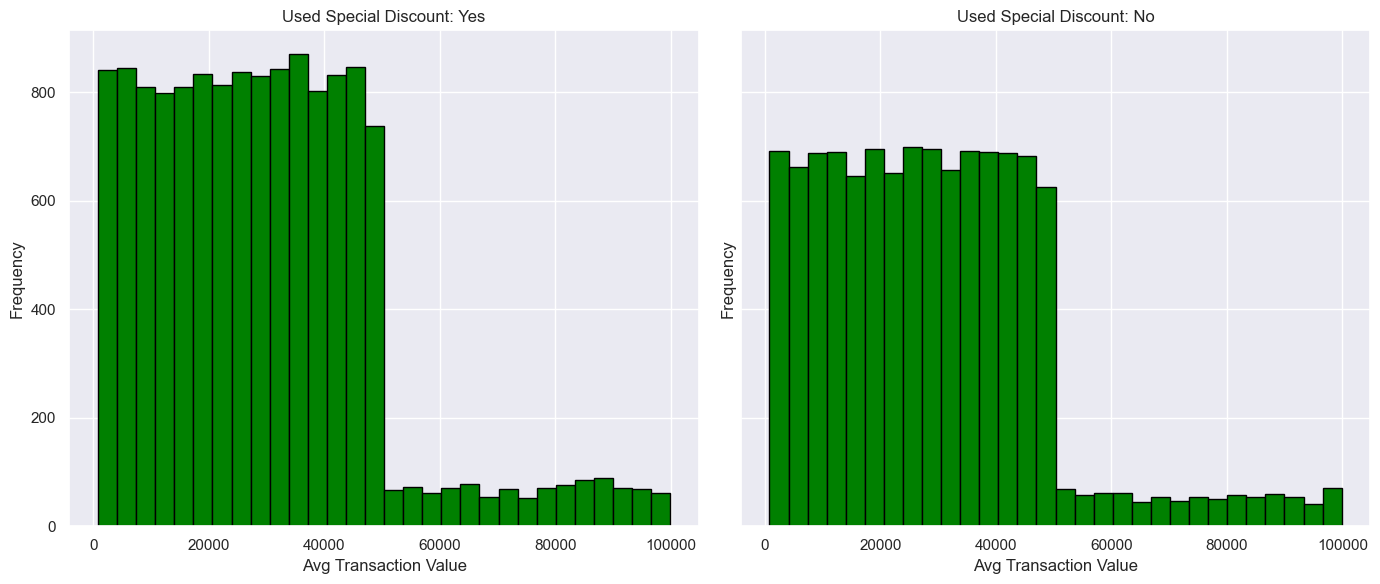

In [331]:
# Combine the columns assuming row alignment
data_df2 = pd.concat([df['used_special_discount'], df['avg_transaction_value']], axis=1)

# Get unique discount values (e.g., 0 and 1 or 'Yes' and 'No')
discount_values = data_df2['used_special_discount'].unique()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, val in enumerate(discount_values):
    subset = data_df2[data_df2['used_special_discount'] == val]['avg_transaction_value']
    axes[i].hist(subset, bins=30, color='green', edgecolor='black')
    axes[i].set_title(f'Used Special Discount: {val}')
    axes[i].set_xlabel('Avg Transaction Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### offer_application_preference  


In [332]:
print("Number of Null:", df['offer_application_preference'].isna().sum())

Number of Null: 0


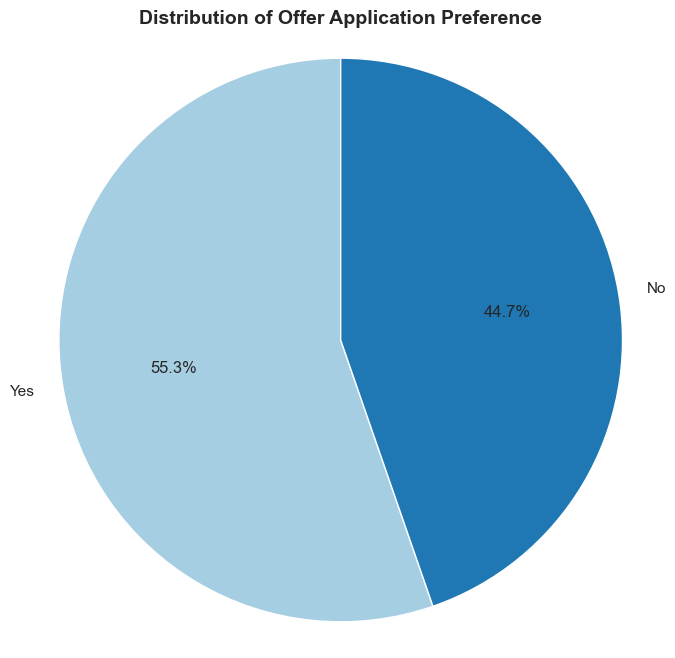

In [333]:

# Get value counts for the 'offer_application_preference' column
offer_application_preference_counts = df['offer_application_preference'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(offer_application_preference_counts, labels=offer_application_preference_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired(range(len(offer_application_preference_counts))))
plt.title('Distribution of Offer Application Preference', fontsize=14, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
plt.show()

### past_complaint                


In [334]:
print("Number of Null:", df['past_complaint'].isna().sum())
print(df['past_complaint'].value_counts())

Number of Null: 0
past_complaint
No     12306
Yes    12059
Name: count, dtype: int64


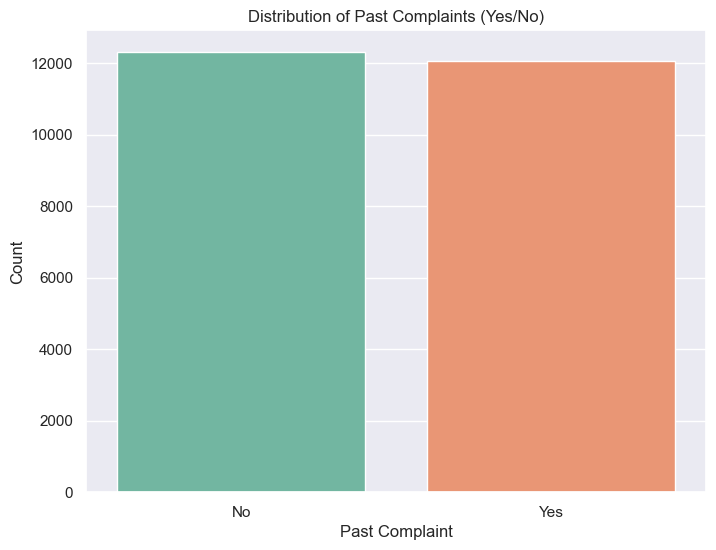

In [335]:
# Plot the distribution of 'past_complaint' with 'hue'
plt.figure(figsize=(8, 6))
sns.countplot(x='past_complaint', data=df, hue='past_complaint', palette='Set2', legend=False)

# Set plot titles and labels
plt.title('Distribution of Past Complaints (Yes/No)')
plt.xlabel('Past Complaint')
plt.ylabel('Count')
plt.grid(True, axis='y')
plt.show()

### complaint_status              


In [336]:
print("Number of Null:", df['complaint_status'].isna().sum())

Number of Null: 0


Complaint Status for 'Yes' in past_complaint:
complaint_status
Unsolved                    3066
Solved                      3025
Solved in Follow-up         2991
No Information Available    2977
Name: count, dtype: int64

Complaint Status for 'No' in past_complaint:
complaint_status
Not Applicable    12306
Name: count, dtype: int64


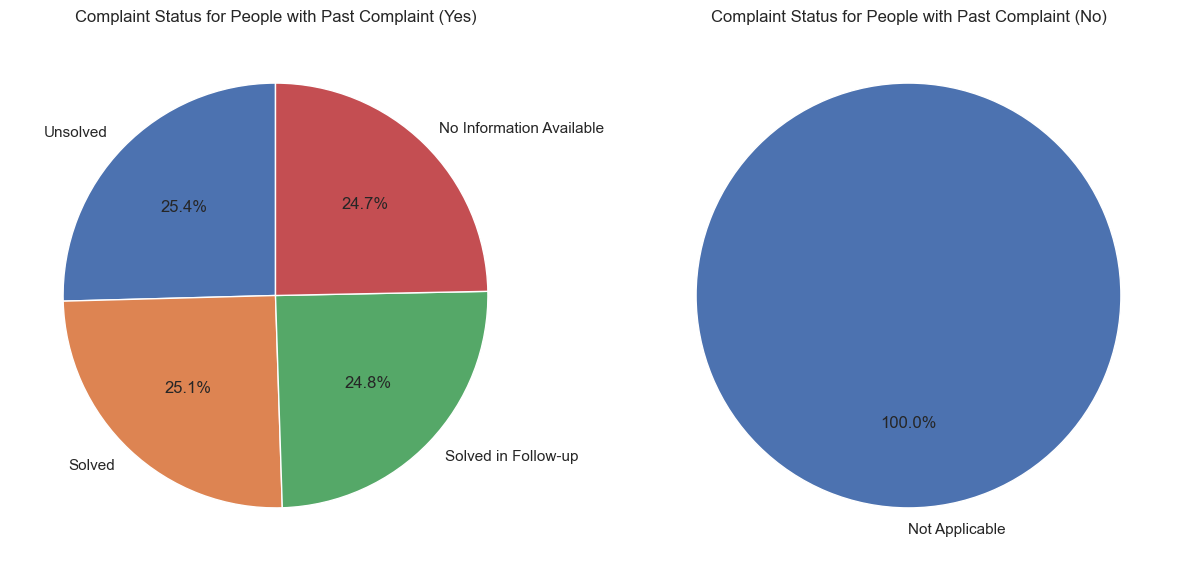

In [337]:

# Ensure that past_complaint and complaint_status are in the expected format
df['past_complaint'] = df['past_complaint'].astype(str)
df['complaint_status'] = df['complaint_status'].astype(str)

# Filter dataset based on 'past_complaint' being 'yes' or 'no'
df_yes = df[df['past_complaint'] == 'Yes']
df_no = df[df['past_complaint'] == 'No']

# Get the counts for complaint_status for each group
complaint_status_yes = df_yes['complaint_status'].value_counts()
complaint_status_no = df_no['complaint_status'].value_counts()

# Print the counts to check for expected categories
print("Complaint Status for 'Yes' in past_complaint:")
print(complaint_status_yes)
print("\nComplaint Status for 'No' in past_complaint:")
print(complaint_status_no)

# Create a pie chart for 'past_complaint' == 'yes'
plt.figure(figsize=(12, 6))

# First pie chart for 'yes' in past_complaint
plt.subplot(1, 2, 1)
if len(complaint_status_yes) > 0:
    plt.pie(complaint_status_yes, labels=complaint_status_yes.index, autopct='%1.1f%%', startangle=90)
else:
    plt.text(0.5, 0.5, 'No Data for Yes Group', horizontalalignment='center', verticalalignment='center')

plt.title("Complaint Status for People with Past Complaint (Yes)")

# Second pie chart for 'no' in past_complaint
plt.subplot(1, 2, 2)
if len(complaint_status_no) > 0:
    plt.pie(complaint_status_no, labels=complaint_status_no.index, autopct='%1.1f%%', startangle=90)
else:
    plt.text(0.5, 0.5, 'No Data for No Group', horizontalalignment='center', verticalalignment='center')

plt.title("Complaint Status for People with Past Complaint (No)")

# Show the pie charts
plt.tight_layout()
plt.show()


We can see that people who did not have past complaint have automatically their own value in Complaint_Status <br>
Since the amount of people who we have No Information Available is large. We will consider it Unknown, as in medium_of_operation. <br>
Additionally, sinch solved and solved in follow up are the same, we will merge them, as solved in follow up gives us no new information. We must make sure of this. The two column which could be impacted are the feedback and churn. We will check the difference between Solved and Solved in Follow up for those columns, in order to make sure we can merge those columns.

In [338]:
import pandas as pd

# Define a function to calculate churn and feedback comparison for each complaint status
def calculate_comparison(df, status):
    # Get feedback distribution percentages
    feedback_counts = df['feedback'].value_counts(normalize=True) * 100

    # Calculate churn rate (percentage of churned)
    churn_rate = df['churn'].mean() * 100
    non_churn_rate = (1 - df['churn'].mean()) * 100

    # Prepare feedback comparison DataFrame
    feedback_comparison_df = pd.DataFrame({
        'Feedback': feedback_counts.index,
        f'{status} (%)': feedback_counts.values
    })

    # Return churn rates for the status
    return feedback_comparison_df, churn_rate, non_churn_rate

# Filter data for 'Solved' and 'Solved in Follow-up'
solved_df = df[df['complaint_status'] == 'Solved']
solved_follow_up_df = df[df['complaint_status'] == 'Solved in Follow-up']

# Calculate feedback and churn comparison for both complaint statuses
solved_feedback_comparison, solved_churn_rate, solved_non_churn_rate = calculate_comparison(solved_df, 'Solved')
solved_follow_up_feedback_comparison, solved_follow_up_churn_rate, solved_follow_up_non_churn_rate = calculate_comparison(solved_follow_up_df, 'Solved in Follow-up')

# Merge the feedback comparison DataFrames
feedback_comparison_df = pd.merge(solved_feedback_comparison, solved_follow_up_feedback_comparison, on='Feedback', how='outer')

# Calculate the difference in feedback percentages and add it as a new column
feedback_comparison_df['Difference'] = feedback_comparison_df[f'Solved (%)'] - feedback_comparison_df[f'Solved in Follow-up (%)']

# Create a churn comparison DataFrame with 'Solved' vs 'Solved in Follow-up' on the X-axis
churn_comparison_df = pd.DataFrame({
    'Churned/Not Churned': ['Not Churned', 'Churned'],
    'Solved (%)': [solved_non_churn_rate, solved_churn_rate],
    'Solved in Follow-up (%)': [solved_follow_up_non_churn_rate, solved_follow_up_churn_rate]
})

# Calculate the difference in churn between 'Solved' and 'Solved in Follow-up'
churn_comparison_df['Difference'] = churn_comparison_df['Solved in Follow-up (%)'] - churn_comparison_df['Solved (%)']

# Display the result
print("Feedback Comparison Table:")
print(feedback_comparison_df)

print("\nChurn Comparison Table:")
print(churn_comparison_df)


Feedback Comparison Table:
                   Feedback  Solved (%)  Solved in Follow-up (%)  Difference
0       No reason specified   17.652893                16.850552    0.802341
1     Poor Customer Service   17.090909                17.251755   -0.160846
2      Poor Product Quality   17.388430                16.950853    0.437577
3              Poor Website   16.528926                18.187897   -1.658971
4  Products always in Stock    3.702479                 3.811434   -0.108955
5     Quality Customer Care    3.471074                 3.577399   -0.106324
6          Reasonable Price    3.834711                 2.808425    1.026285
7              Too many ads   16.826446                17.151454   -0.325008
8     User Friendly Website    3.504132                 3.410231    0.093902

Churn Comparison Table:
  Churned/Not Churned  Solved (%)  Solved in Follow-up (%)  Difference
0         Not Churned   73.057851                72.450685   -0.607166
1             Churned   26.942149   

We can see the difference is not so drastic so we can merge them.

In [339]:
# Replace values in the 'complaint_status' column
df['complaint_status'] = df['complaint_status'].replace({
    'Solved in Follow-up': 'Solved',
    'No Information Available': 'Unknown',
    'Not Applicable': 'No Past Complaint'
})




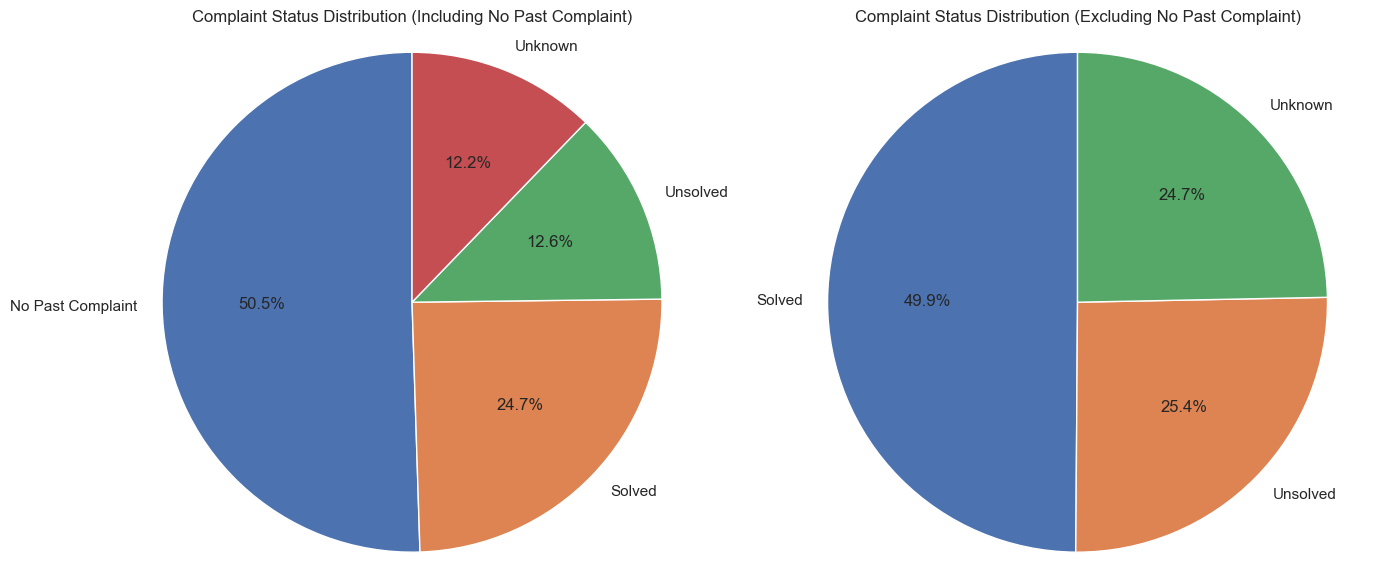

In [340]:

# Create a figure with two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Pie Chart 1: Including "No Past Complaint"
complaint_status_counts_inclusive = df['complaint_status'].value_counts()
axes[0].pie(complaint_status_counts_inclusive, labels=complaint_status_counts_inclusive.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Complaint Status Distribution (Including No Past Complaint)')
axes[0].axis('equal')  # Equal aspect ratio ensures that pie chart is circular.

# Pie Chart 2: Excluding "No Past Complaint"
complaint_status_counts_exclusive = df[df['complaint_status'] != 'No Past Complaint']['complaint_status'].value_counts()
axes[1].pie(complaint_status_counts_exclusive, labels=complaint_status_counts_exclusive.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Complaint Status Distribution (Excluding No Past Complaint)')
axes[1].axis('equal')  # Equal aspect ratio ensures that pie chart is circular.

# Show the plots
plt.tight_layout()  # Adjusts subplots to fit into the figure area
plt.show()

### feedback                      


In [341]:
print("Number of Null:", df['feedback'].isna().sum())

Number of Null: 0


In [342]:
# Define the feedback items
positive_feedback = [
    "Products always in Stock", "Reasonable Price", 
    "User Friendly Website", "Quality Customer Care"
]

negative_feedback = [
    "Poor Product Quality", "Too many ads",
    "Poor Customer Service", "Poor Website"
]

# Function to categorize feedback as Positive or Negative
def categorize_feedback(feedback):
    if feedback in positive_feedback:
        return 'Positive'
    elif feedback in negative_feedback:
        return 'Negative'
    else:
        return 'Unknown'  # If feedback doesn't match any category, mark as Unknown

# Apply the function to the 'feedback' column and create a new column 'feedback_kind'
df['feedback_kind'] = df['feedback'].apply(categorize_feedback)

# Display the first few rows to check the new column
print(df[['feedback', 'feedback_kind']].head())

               feedback feedback_kind
0  Poor Product Quality      Negative
1  Poor Product Quality      Negative
2  Poor Product Quality      Negative
3          Too many ads      Negative
4   No reason specified       Unknown


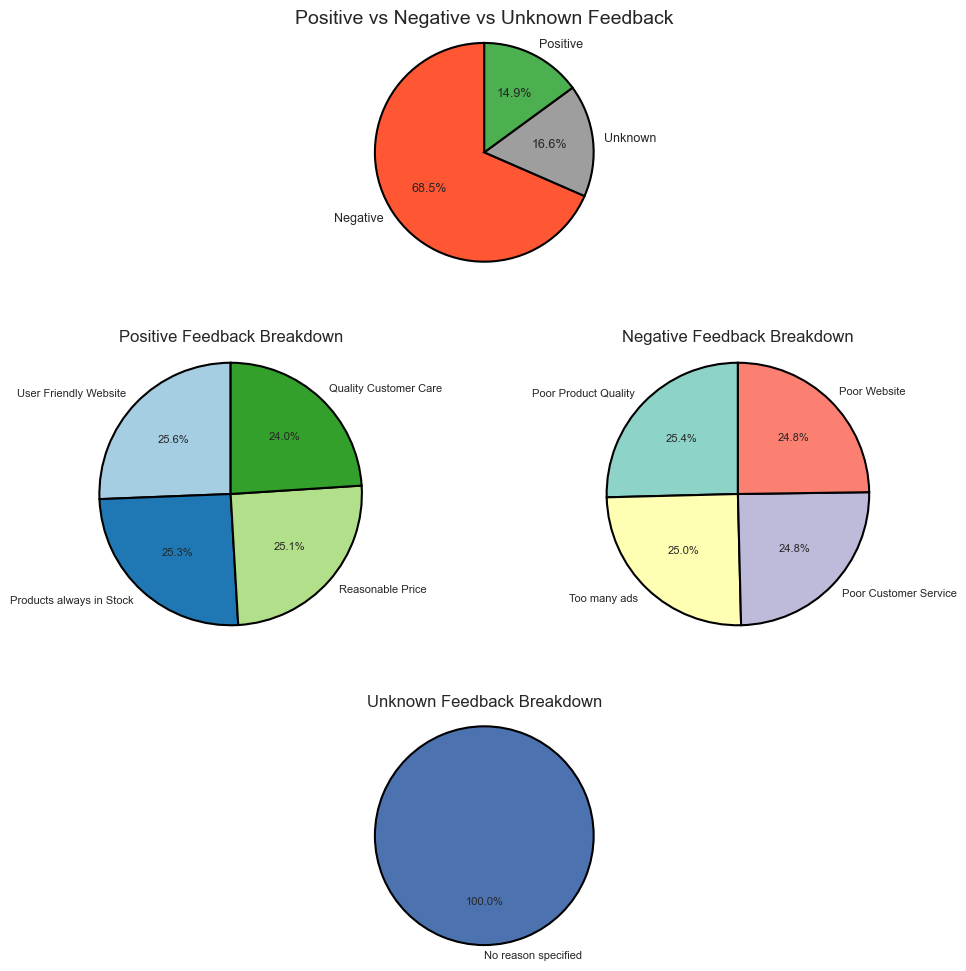

In [343]:
import matplotlib.gridspec as gridspec

# Prepare counts
feedback_kind_counts = df['feedback_kind'].value_counts()

# Breakdown counts
positive_feedback_counts = df[df['feedback_kind'] == 'Positive']['feedback'].value_counts()
negative_feedback_counts = df[df['feedback_kind'] == 'Negative']['feedback'].value_counts()
unknown_feedback_counts = df[df['feedback_kind'] == 'Unknown']['feedback'].value_counts()

# Set up figure and GridSpec layout
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1.2, 1])

# 1. Pie Chart: Positive vs Negative vs Unknown Feedback
ax1 = plt.subplot(gs[0, :])
kind_colors = {
    'Positive': '#4CAF50',
    'Negative': '#FF5733',
    'Unknown': '#9E9E9E'  # gray for unknown
}

# Match colors to available kinds
kind_colors_list = [kind_colors.get(kind, '#CCCCCC') for kind in feedback_kind_counts.index]

wedges1, texts1, autotexts1 = ax1.pie(
    feedback_kind_counts, 
    labels=feedback_kind_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=kind_colors_list,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
    textprops={'fontsize': 9}
)
ax1.set_title('Positive vs Negative vs Unknown Feedback', fontsize=14)
ax1.axis('equal')

# 2. Pie Chart: Positive feedback breakdown
ax2 = plt.subplot(gs[1, 0])
wedges2, texts2, autotexts2 = ax2.pie(
    positive_feedback_counts, 
    labels=positive_feedback_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=plt.cm.Paired(range(len(positive_feedback_counts))),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
    textprops={'fontsize': 8}
)
ax2.set_title('Positive Feedback Breakdown', fontsize=12)
ax2.axis('equal')

# 3. Pie Chart: Negative feedback breakdown
ax3 = plt.subplot(gs[1, 1])
wedges3, texts3, autotexts3 = ax3.pie(
    negative_feedback_counts, 
    labels=negative_feedback_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=plt.cm.Set3(range(len(negative_feedback_counts))),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
    textprops={'fontsize': 8}
)
ax3.set_title('Negative Feedback Breakdown', fontsize=12)
ax3.axis('equal')

# 4. Pie Chart: Unknown feedback breakdown (Single Option)
ax4 = plt.subplot(gs[2, :])
ax4.pie([1], labels=unknown_feedback_counts.index, autopct='%1.1f%%', startangle=90, 
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}, textprops={'fontsize': 8})
ax4.set_title('Unknown Feedback Breakdown', fontsize=12)
ax4.axis('equal')

# Adjust layout
plt.subplots_adjust(hspace=0.3)
plt.show()


### churn                         


In [344]:
print("Number of Null:", df['churn'].isna().sum())

Number of Null: 0


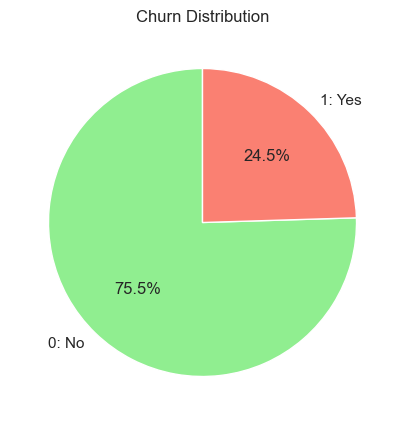

In [345]:
# Pie chart
plt.figure(figsize=(5,5))
plt.pie(churn_counts, labels=['0: No', '1: Yes'], autopct='%1.1f%%', colors=['lightgreen', 'salmon'], startangle=90)
plt.title('Churn Distribution')
plt.show()

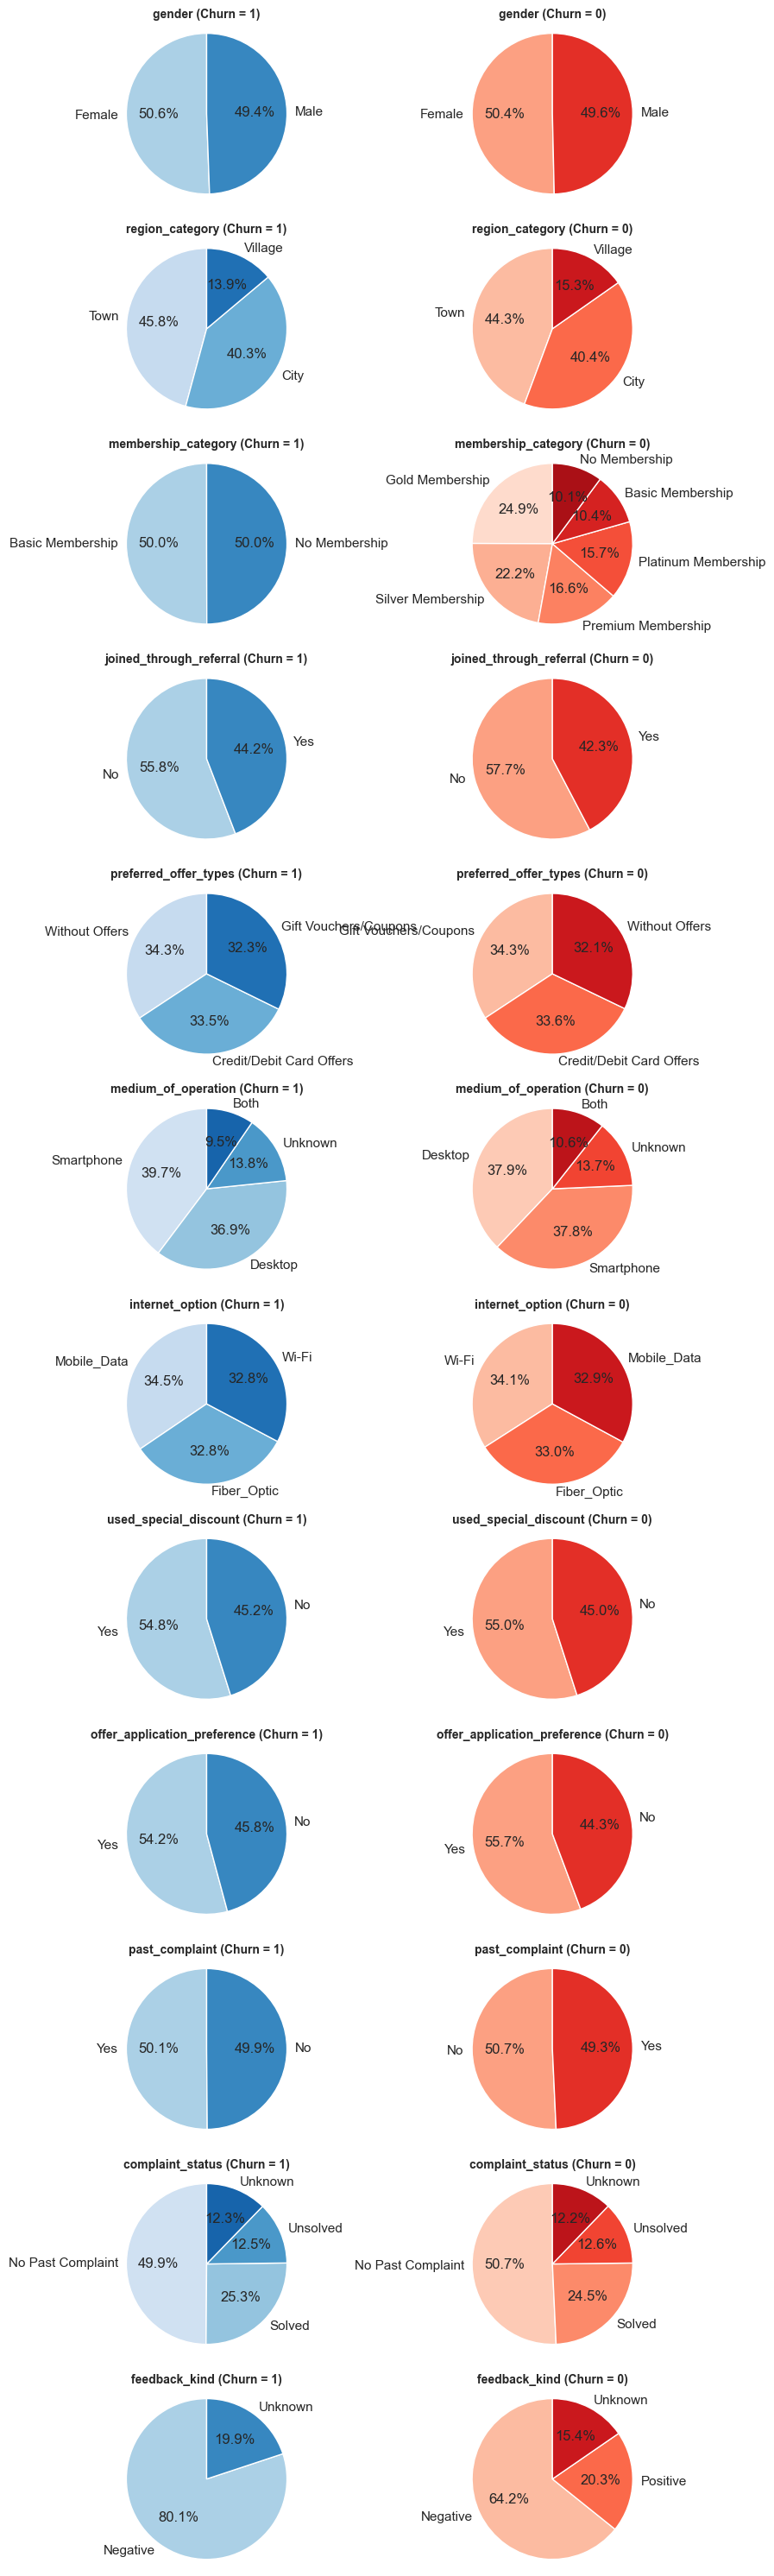

In [346]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate data by churn
churn_1 = df[df['churn'] == 1]
churn_0 = df[df['churn'] == 0]

# Select only categorical columns and exclude 'joining_date'
categorical_columns = [col for col in df.select_dtypes(include=['object', 'category']).columns if col != 'joining_date']

# Filter to only columns with less than or equal to 8 unique values (good for pie)
filtered_columns = [col for col in categorical_columns if df[col].nunique(dropna=True) <= 8]

# Set up grid: rows = num columns, cols = 2 (churn=1 and churn=0)
num_rows = len(filtered_columns)
fig, axes = plt.subplots(num_rows, 2, figsize=(8, num_rows * 2.5))

# Loop over columns
for i, col in enumerate(filtered_columns):
    # Churn = 1
    churn_1_counts = churn_1[col].value_counts(normalize=True)
    axes[i, 0].pie(churn_1_counts, labels=churn_1_counts.index, autopct='%1.1f%%', startangle=90, 
                   colors=sns.color_palette("Blues", len(churn_1_counts)))
    axes[i, 0].set_title(f'{col} (Churn = 1)', fontsize=10, fontweight='bold')
    axes[i, 0].axis('equal')

    # Churn = 0
    churn_0_counts = churn_0[col].value_counts(normalize=True)
    axes[i, 1].pie(churn_0_counts, labels=churn_0_counts.index, autopct='%1.1f%%', startangle=90, 
                   colors=sns.color_palette("Reds", len(churn_0_counts)))
    axes[i, 1].set_title(f'{col} (Churn = 0)', fontsize=10, fontweight='bold')
    axes[i, 1].axis('equal')

plt.tight_layout()
plt.show()


We can see a difference between the churn groups in columns membership_category and feedback_kind <br>
Membership category for those churned turns out to be only no membership or basic membership.
Feedback kind for those chosed turns out to be unknown or negative only and not positive.

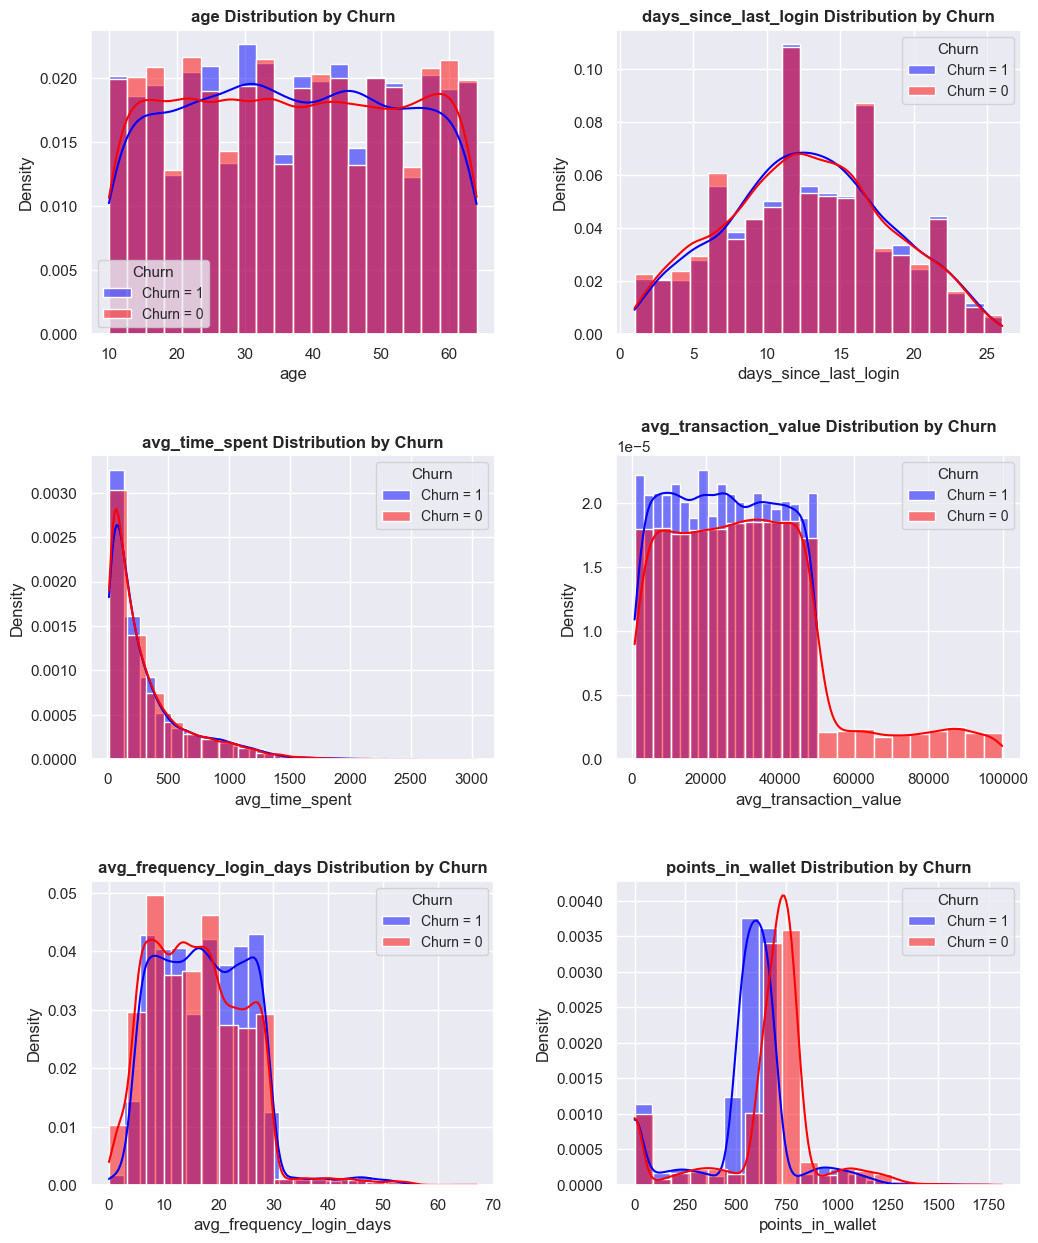

In [347]:
# Separate data by churn
churn_1 = df[df['churn'] == 1]
churn_0 = df[df['churn'] == 0]

# Get numerical columns and EXCLUDE 'churn'
numerical_columns = [col for col in df.select_dtypes(include=['float64', 'int64']).columns if col != 'churn']

# Set up the plotting area
num_plots = len(numerical_columns)
num_rows = (num_plots + 1) // 2  # Calculate rows dynamically based on the number of columns
num_cols = 2  # 2 columns layout

# Set up the figure with subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 5))
axes = axes.flatten()  # Flatten axes for easy iteration

# Loop through each numerical column to plot the histograms
for i, col in enumerate(numerical_columns):
    if i < len(axes):
        # Plot histogram for churn = 1
        sns.histplot(churn_1[col], kde=True, stat="density", color='blue', bins=20, ax=axes[i], label='Churn = 1', legend=False)
        
        # Plot histogram for churn = 0
        sns.histplot(churn_0[col], kde=True, stat="density", color='red', bins=20, ax=axes[i], label='Churn = 0', legend=False)
        
        # Add legend and titles
        axes[i].legend(title='Churn', fontsize=10, title_fontsize=11)
        axes[i].set_title(f'{col} Distribution by Churn', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Density')

# Remove any empty subplots if num_plots is odd
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

We can see a difference in points_in_wallet - mean is different between the two groups, and average transaction - for those churn=1 more spent less than 50,000 than those who churn=0. churn=0 also spent more than 50,000 on average vs. churn=1 who rarely did so.

In [348]:
# Get numerical columns (excluding churn if needed)
numerical_columns = [col for col in df.select_dtypes(include=['float64', 'int64']).columns]

# Calculate mean and std for each numerical column
mean_values = df[numerical_columns].mean()
std_values = df[numerical_columns].std()

# Create condition: abs difference > 3 * std
outliers_condition = ((df[numerical_columns] - mean_values).abs()) > (3 * std_values)

# Count outliers per column
outliers_count = outliers_condition.sum()

# Show results
print("Number of outliers (values more than 3 standard deviations from the mean) in each column:")
print(outliers_count)


Number of outliers (values more than 3 standard deviations from the mean) in each column:
age                           0
days_since_last_login         0
avg_time_spent              425
avg_transaction_value       469
avg_frequency_login_days    261
points_in_wallet             60
churn                         0
dtype: int64


In [349]:
# Get only numerical columns
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Start with a mask where all rows are True
mask = pd.Series(True, index=df.index)

# Loop over each numerical column to update the mask
for column in numerical_columns:
    mean = df[column].mean()
    std = df[column].std()
    # Update mask to keep rows within 3 standard deviations
    mask &= df[column].between(mean - 3 * std, mean + 3 * std)

# Apply mask to filter the dataframe
df_cleaned = df[mask]

print(f"Original rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_cleaned)}")


Original rows: 24365
Rows after removing outliers: 23168


# Creating Clean Dataset

In [350]:
df.head()

,customer_id,Name,age,gender,region_category,membership_category,joining_date,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn,feedback_kind
0,fffe43004900440033003200390032003400,Dusty Dunneback,30,Female,Village,No Membership,2017-08-09,Yes,Gift Vouchers/Coupons,Desktop,Mobile_Data,20.0,118.390000,10579.56,24.0,610.360000,Yes,No,No,No Past Complaint,Poor Product Quality,1,Negative
1,fffe43004900440036003200310038003600,Dorine Vanduyn,55,Male,Village,Silver Membership,2016-02-09,No,Credit/Debit Card Offers,Smartphone,Wi-Fi,15.0,179.420000,22963.05,27.0,694.650000,Yes,No,No,No Past Complaint,Poor Product Quality,0,Negative
2,fffe430049004400350032003200,Christene Pulver,47,Male,City,Basic Membership,2017-06-11,Yes,Credit/Debit Card Offers,Unknown,Wi-Fi,23.0,42.230000,32604.41,17.0,520.620000,Yes,No,No,No Past Complaint,Poor Product Quality,1,Negative
3,fffe43004900440032003200380034003600,Brendan Enciso,18,Male,Town,Gold Membership,2016-02-09,No,Credit/Debit Card Offers,Desktop,Mobile_Data,7.0,1035.833706,48913.61,27.0,1150.093442,Yes,No,No,No Past Complaint,Too many ads,0,Negative
4,fffe43004900440035003600320032003100,Lizette Lemons,28,Female,City,No Membership,2017-07-16,Yes,Credit/Debit Card Offers,Both,Fiber_Optic,10.0,449.770000,20010.02,14.0,653.040000,Yes,Yes,Yes,Unknown,No reason specified,0,Unknown


In [351]:
df.shape

(24365, 23)

In [352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24365 entries, 0 to 24783
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   customer_id                   24365 non-null  object        
 1   Name                          24365 non-null  object        
 2   age                           24365 non-null  int64         
 3   gender                        24365 non-null  object        
 4   region_category               24365 non-null  object        
 5   membership_category           24365 non-null  object        
 6   joining_date                  24365 non-null  datetime64[ns]
 7   joined_through_referral       24365 non-null  object        
 8   preferred_offer_types         24365 non-null  object        
 9   medium_of_operation           24365 non-null  object        
 10  internet_option               24365 non-null  object        
 11  days_since_last_login         243

In [353]:
# Count total null values in the entire dataframe
total_nulls = df.isnull().sum().sum()

print(f"Total null values in clean_df: {total_nulls}")

Total null values in clean_df: 0


In [354]:
# Save the cleaned DataFrame to a CSV file
df.to_csv('cleaned_churn_dataset_train.csv', index=False)

print("CSV file 'cleaned_churn_dataset_train.csv' has been created.")

CSV file 'cleaned_churn_dataset_train.csv' has been created.
